# Final Project Notebook
### Data Science for Healthcare

---
## Project framework

Please read these instructions carefully before starting.

**Your role:** you are a data science team tasked with analysing a real clinical dataset. No explanation of the variables is provided: you will need to explore them, form hypotheses, and find answers.

**The instructor's role:** your instructor acts as the *clinical expert* for this project. You can (and should) consult him whenever you have questions about the clinical meaning of a variable, the plausibility of an analytical choice, or the interpretation of results. Any clinical question you bring will be answered and discussed together.

**No pre-defined path:** this dataset is huge, a lot of different analyses can be performed, so don't search for 'the right one'. Many of them can be right! Just discuss them with the instructor.

**How to document your work:**
At the end of every phase you may add a markdown cell where the team records the choices made and their clinical rationale. This is not a technical comment on the code, it is the trace of your reasoning. **This part is optional**, but it may be useful to you in the final phase of poster composition.

---

## Phase 0: Setup and dataset loading

### Imports

In [ ]:
# Install the library if needed (run once)
!pip install ucimlrepo

In [ ]:
!pip install gower

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)
import seaborn as sns
import gower
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
sns.set(style="whitegrid")

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    GridSearchCV
)

from sklearn.feature_selection import VarianceThreshold, RFE

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

### Data Loading

In [ ]:
# =========================================================
# LOAD SUPPORT2 DATASET
# =========================================================

support2 = fetch_ucirepo(id=880)

# =========================================================
# FULL ORIGINAL DATAFRAME
# (contains Features + Targets + Other variables)
# =========================================================

df_full = support2.data.original.copy()

print("Dataset loaded successfully.")
print(f"Full dataframe shape: {df_full.shape}")

# =========================================================
# DEFINE X AND y
# =========================================================

# Target variables
target_cols = ['death', 'hospdead', 'sfdm2']

# Remove targets from X
# -> keeps Features + Other variables (including d.time, slos, etc.)
X = df_full.drop(columns=target_cols).copy()

# Define y
y = df_full[target_cols].copy()

print(f"\nX (features + other) shape: {X.shape}")
print(f"y (targets) shape: {y.shape}")

# =========================================================
# CHECK IMPORTANT COLUMNS
# =========================================================

print("\nColumns now included in X:")
print([col for col in ['ca', 'd.time', 'slos'] if col in X.columns])

# =========================================================
# OPTIONAL: VERIFY
# =========================================================

print("\nFirst rows of selected columns:")
print(X[['ca', 'd.time', 'slos']].head())

Dataset loaded successfully.
Full dataframe shape: (9105, 48)

X (features + other) shape: (9105, 45)
y (targets) shape: (9105, 3)

Columns now included in X:
['ca', 'd.time', 'slos']

First rows of selected columns:
           ca  d.time  slos
0  metastatic    2029     5
1          no       4     4
2          no      47    17
3  metastatic     133     3
4          no    2029    16


In [ ]:
# Dataset metadata
support2.metadata

{'uci_id': 880,
 'name': 'SUPPORT2',
 'repository_url': 'https://archive.ics.uci.edu/dataset/880/support2',
 'data_url': 'https://archive.ics.uci.edu/static/public/880/data.csv',
 'abstract': "This dataset comprises 9105 individual critically ill patients across 5 United States medical centers, accessioned throughout 1989-1991 and 1992-1994.\nEach row concerns hospitalized patient records who met the inclusion and exclusion criteria for nine disease categories: acute respiratory failure, chronic obstructive pulmonary disease, congestive heart failure, liver disease, coma, colon cancer, lung cancer, multiple organ system failure with malignancy, and multiple organ system failure with sepsis. The goal is to determine these patients' 2- and 6-month survival rates based on several physiologic, demographics, and disease severity information. \nIt is an important problem because it addresses the growing national concern over patients' loss of control near the end of life. It enables earlier 

In [ ]:
# Variable information: name, role, type
support2.variables

,name,role,type,demographic,description,units,missing_values
0,id,ID,Integer,None,None,None,no
1,age,Feature,Continuous,Age,Age of the patients in years,years,no
2,death,Target,Continuous,None,Death at any time up to National Death Index (NDI) data on 31 of December of 1994. Some patients are discharged before the end of the study and are not followed up. The authors looked up the information about death.,None,no
3,sex,Feature,Categorical,Sex,"Gender of the patient. Listed values are {male, female}.",None,no
4,hospdead,Target,Binary,None,Death in hospital,None,no
5,slos,Other,Continuous,None,Days from Study Entry to Discharge,None,no
6,d.time,Other,Continuous,None,Days of follow-up,None,no
7,dzgroup,Feature,Categorical,None,"The patient's disease sub category amogst ARF/MOSF w/Sepsis, CHF, COPD, Cirrhosis, Colon Cancer, Coma, Lung Cancer, MOSF w/Malig.",None,no
8,dzclass,Feature,Categorical,None,"The patient's disease category amongst ""ARF/MOSF"", ""COPD/CHF/Cirrhosis"", ""Cancer"", ""Coma"".",None,no
9,num.co,Feature,Continuous,None,The number of simultaneous diseases (or comorbidities) exhibited by the patient. Values are ordinal with higher values indicating worse condition and chances of survival.,None,no


---
## Phase 1: Exploration and Dataset understanding

In [ ]:
# =========================================================
# GENERAL INFO
# =========================================================

print("\n" + "="*60)
print("DATAFRAME INFO")
print("="*60)
print(X.info())


DATAFRAME INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   sex       9105 non-null   object 
 3   slos      9105 non-null   int64  
 4   d.time    9105 non-null   int64  
 5   dzgroup   9105 non-null   object 
 6   dzclass   9105 non-null   object 
 7   num.co    9105 non-null   int64  
 8   edu       7471 non-null   float64
 9   income    6123 non-null   object 
 10  scoma     9104 non-null   float64
 11  charges   8933 non-null   float64
 12  totcst    8217 non-null   float64
 13  totmcst   5630 non-null   float64
 14  avtisst   9023 non-null   float64
 15  race      9063 non-null   object 
 16  sps       9104 non-null   float64
 17  aps       9104 non-null   float64
 18  surv2m    9104 non-null   float64
 19  surv6m    9104 non-null   float64
 20  hday      9105

In [ ]:
# =========================================================
# MISSING VALUES
# =========================================================

print("\n" + "="*60)
print("MISSING VALUES PER COLUMN")
print("="*60)
missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

print("\nTotal missing values:", X.isnull().sum().sum())



MISSING VALUES PER COLUMN
adlp       5641
urine      4862
glucose    4500
bun        4352
totmcst    3475
alb        3372
income     2982
adls       2867
bili       2601
pafi       2325
ph         2284
prg2m      1649
edu        1634
prg6m      1633
totcst      888
wblc        212
charges     172
avtisst      82
crea         67
race         42
dnrday       30
dnr          30
scoma         1
surv6m        1
sps           1
aps           1
surv2m        1
resp          1
temp          1
meanbp        1
hrt           1
sod           1
dtype: int64

Total missing values: 45710


In [ ]:
# =========================================================
# NUMERICAL SUMMARY
# =========================================================

print("\n" + "="*60)
print("NUMERICAL FEATURES SUMMARY")
print("="*60)
print(X.describe())


NUMERICAL FEATURES SUMMARY
                id          age         slos       d.time       num.co  \
count  9105.000000  9105.000000  9105.000000  9105.000000  9105.000000   
mean   4553.000000    62.650823    17.863042   478.449863     1.868644   
std    2628.531434    15.593710    22.006440   560.383272     1.344409   
min       1.000000    18.041990     3.000000     3.000000     0.000000   
25%    2277.000000    52.797000     6.000000    26.000000     1.000000   
50%    4553.000000    64.856990    11.000000   233.000000     2.000000   
75%    6829.000000    73.998960    20.000000   761.000000     3.000000   
max    9105.000000   101.847960   343.000000  2029.000000     9.000000   

               edu        scoma       charges         totcst        totmcst  \
count  7471.000000  9104.000000  8.933000e+03    8217.000000    5630.000000   
mean     11.747691    12.058546  5.999579e+04   30825.867768   28828.877838   
std       3.447743    24.636694  1.026488e+05   45780.820986   43604

In [ ]:
# =========================================================
# CATEGORICAL SUMMARY
# =========================================================

categorical_cols = X.select_dtypes(include=['object', 'category']).columns

print("\n" + "="*60)
print("CATEGORICAL COLUMNS")
print("="*60)
print(categorical_cols.tolist())


CATEGORICAL COLUMNS
['sex', 'dzgroup', 'dzclass', 'income', 'race', 'ca', 'dnr']


In [ ]:
# =========================================================
# UNIQUE VALUES FOR CATEGORICAL VARIABLES
# =========================================================

print("\n" + "="*60)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*60)

for col in categorical_cols:
    print(f"\nCOLUMN: {col}")
    print(f"Number of unique values: {X[col].nunique()}")
    print(X[col].unique()[:20])  # show first 20 unique values



UNIQUE VALUES IN CATEGORICAL COLUMNS

COLUMN: sex
Number of unique values: 2
['male' 'female']

COLUMN: dzgroup
Number of unique values: 8
['Lung Cancer' 'Cirrhosis' 'ARF/MOSF w/Sepsis' 'Coma' 'CHF' 'Colon Cancer'
 'COPD' 'MOSF w/Malig']

COLUMN: dzclass
Number of unique values: 4
['Cancer' 'COPD/CHF/Cirrhosis' 'ARF/MOSF' 'Coma']

COLUMN: income
Number of unique values: 4
['$11-$25k' 'under $11k' nan '$25-$50k' '>$50k']

COLUMN: race
Number of unique values: 5
['other' 'white' 'black' 'hispanic' 'asian' nan]

COLUMN: ca
Number of unique values: 3
['metastatic' 'no' 'yes']

COLUMN: dnr
Number of unique values: 3
['no dnr' nan 'dnr after sadm' 'dnr before sadm']


In [ ]:
# =========================================================
# VALUE COUNTS (TOP VALUES)
# =========================================================

print("\n" + "="*60)
print("TOP VALUE COUNTS")
print("="*60)

for col in categorical_cols:
    print(f"\nCOLUMN: {col}")
    print(X[col].value_counts(dropna=False).head(10))



TOP VALUE COUNTS

COLUMN: sex
sex
male      5125
female    3980
Name: count, dtype: int64

COLUMN: dzgroup
dzgroup
ARF/MOSF w/Sepsis    3515
CHF                  1387
COPD                  967
Lung Cancer           908
MOSF w/Malig          712
Coma                  596
Colon Cancer          512
Cirrhosis             508
Name: count, dtype: int64

COLUMN: dzclass
dzclass
ARF/MOSF              4227
COPD/CHF/Cirrhosis    2862
Cancer                1420
Coma                   596
Name: count, dtype: int64

COLUMN: income
income
NaN           2982
under $11k    2855
$11-$25k      1527
$25-$50k      1057
>$50k          684
Name: count, dtype: int64

COLUMN: race
race
white       7191
black       1391
hispanic     290
other        112
asian         79
NaN           42
Name: count, dtype: int64

COLUMN: ca
ca
no            5995
metastatic    1858
yes           1252
Name: count, dtype: int64

COLUMN: dnr
dnr
no dnr             5880
dnr after sadm     2956
dnr before sadm     239
NaN          

In [ ]:
# =========================================================
# CHECK DUPLICATES
# =========================================================

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)

duplicates = X.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")



DUPLICATE ROWS
Number of duplicate rows: 0


In [ ]:
# =========================================================
# TARGET INSPECTION
# =========================================================

print("\n" + "="*60)
print("TARGET DATA TYPES")
print("="*60)
print(y.dtypes)

print("\n" + "="*60)
print("TARGET SUMMARY")
print("="*60)
print(y.describe(include='all'))


TARGET DATA TYPES
death        int64
hospdead     int64
sfdm2       object
dtype: object

TARGET SUMMARY
              death     hospdead             sfdm2
count   9105.000000  9105.000000              7705
unique          NaN          NaN                 5
top             NaN          NaN  <2 mo. follow-up
freq            NaN          NaN              3123
mean       0.681054     0.259198               NaN
std        0.466094     0.438219               NaN
min        0.000000     0.000000               NaN
25%        0.000000     0.000000               NaN
50%        1.000000     0.000000               NaN
75%        1.000000     1.000000               NaN
max        1.000000     1.000000               NaN


In [ ]:
# =========================================================
# UNIQUE VALUES FOR TARGET VARIABLES
# =========================================================

print("\n" + "="*60)
print("UNIQUE VALUES IN TARGET COLUMNS")
print("="*60)

for col in y:
    print(f"\nCOLUMN: {col}")
    print(f"Number of unique values: {y[col].nunique()}")
    print(y[col].unique()[:20])  # show first 20 unique values



UNIQUE VALUES IN TARGET COLUMNS

COLUMN: death
Number of unique values: 2
[0 1]

COLUMN: hospdead
Number of unique values: 2
[0 1]

COLUMN: sfdm2
Number of unique values: 5
[nan '<2 mo. follow-up' 'no(M2 and SIP pres)' 'SIP>=30'
 'adl>=4 (>=5 if sur)' 'Coma or Intub']


### Filtering Patients

In [ ]:
# =========================================================
# FILTER DATASET BASED ON COLUMN 'ca'
# Keep only patients with:
#   - 'metastatic'
#   - 'yes'
# Then create a binary column:
#   metastatic = 1 if ca == 'metastatic'
#   metastatic = 0 if ca == 'yes'
# =========================================================

# Check unique values first (optional but recommended)
print(X['ca'].value_counts(dropna=False))

# Define allowed categories
allowed_ca = ['metastatic', 'yes']

# Create boolean mask
mask = X['ca'].isin(allowed_ca)

# Filter X and y
X_filtered = X.loc[mask].copy()
y_filtered = y.loc[mask].copy()

# Create new binary column
X_filtered['metastatic'] = (
    X_filtered['ca'] == 'metastatic'
).astype(int)

# Optional: check results
print("\nFiltered dataset shapes:")
print(f"X_filtered shape: {X_filtered.shape}")
print(f"y_filtered shape: {y_filtered.shape}")

print("\nNew metastatic column counts:")
print(X_filtered['metastatic'].value_counts())

print("\nOriginal 'ca' distribution after filtering:")
print(X_filtered['ca'].value_counts())


ca
no            5995
metastatic    1858
yes           1252
Name: count, dtype: int64

Filtered dataset shapes:
X_filtered shape: (3110, 46)
y_filtered shape: (3110, 3)

New metastatic column counts:
metastatic
1    1858
0    1252
Name: count, dtype: int64

Original 'ca' distribution after filtering:
ca
metastatic    1858
yes           1252
Name: count, dtype: int64


In [ ]:
# =========================================================
# ADDITIONAL FILTER:
# Keep only patients who survived beyond 60 days
#
# Remove patients with:
#   d.time <= 60  AND  death == 1
#
# NOTE:
# - d.time is in X_filtered
# - death is in y_filtered
# - indices are preserved automatically using .loc[mask]
# =========================================================

# Create survival mask
survival_mask = ~(
    (X_filtered['d.time'] <= 60) &
    (y_filtered['death'] == 1)
)

# Apply filter while preserving indices
X_final = X_filtered.loc[survival_mask].copy()
y_final = y_filtered.loc[survival_mask].copy()

# =========================================================
# OPTIONAL CHECKS
# =========================================================

print("\nFinal dataset shapes:")
print(f"X_final shape: {X_final.shape}")
print(f"y_final shape: {y_final.shape}")

print("\nDeath distribution after filtering:")
print(y_final['death'].value_counts(dropna=False))

print("\nPatients with d.time <= 60 and death == 1 remaining:")
print(
    (
        (X_final['d.time'] <= 60) &
        (y_final['death'] == 1)
    ).sum()
)

# =========================================================
# VERIFY INDEX ALIGNMENT
# =========================================================

print("\nIndices aligned:")
print(X_final.index.equals(y_final.index))


Final dataset shapes:
X_final shape: (1848, 46)
y_final shape: (1848, 3)

Death distribution after filtering:
death
1    1349
0     499
Name: count, dtype: int64

Patients with d.time <= 60 and death == 1 remaining:
0

Indices aligned:
True


### Target Definition

In [ ]:
# =========================================================
# DEFINE FINAL TARGET: sfdm2 ONLY
# =========================================================

# Keep only the column 'sfdm2' from y
y_final = y_final[['sfdm2']].copy()

# =========================================================
# CHECK DISTRIBUTION + MISSING VALUES
# =========================================================

print("\nDistribution of 'sfdm2' (including NaN):")
print(y_final['sfdm2'].value_counts(dropna=False))

print("\nNumber of missing values (NaN) in sfdm2:")
print(y_final['sfdm2'].isna().sum())

# =========================================================
# REMOVE NaN TARGETS (IMPORTANT FOR ML)
# =========================================================

mask_notna = y_final['sfdm2'].notna()

X_final = X_final.loc[mask_notna].copy()
y_final = y_final.loc[mask_notna].copy()

# =========================================================
# FINAL CHECK
# =========================================================

print("\nAfter removing NaN targets:")
print(f"X_final shape: {X_final.shape}")
print(f"y_final shape: {y_final.shape}")

print("\nFinal sfdm2 distribution:")
print(y_final['sfdm2'].value_counts())


Distribution of 'sfdm2' (including NaN):
sfdm2
no(M2 and SIP pres)    973
NaN                    477
adl>=4 (>=5 if sur)    247
SIP>=30                144
Coma or Intub            7
Name: count, dtype: int64

Number of missing values (NaN) in sfdm2:
477

After removing NaN targets:
X_final shape: (1371, 46)
y_final shape: (1371, 1)

Final sfdm2 distribution:
sfdm2
no(M2 and SIP pres)    973
adl>=4 (>=5 if sur)    247
SIP>=30                144
Coma or Intub            7
Name: count, dtype: int64



Target distribution:
target
0    973
1    398
Name: count, dtype: int64


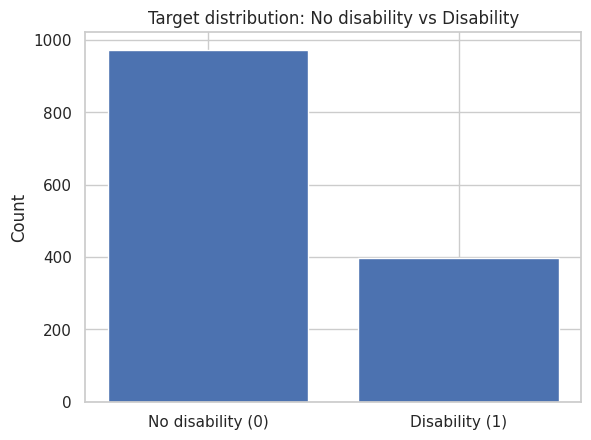

In [ ]:
# =========================================================
# BINARIZE TARGET: disability vs no disability
# =========================================================
# 0 = no disability ("no(M2 and SIP pres)")
# 1 = disability (all other categories)

y_final['target'] = (y_final['sfdm2'] != 'no(M2 and SIP pres)').astype(int)

# Drop original multiclass column
y_final = y_final.drop(columns=['sfdm2'])

# =========================================================
# DISTRIBUTION
# =========================================================

counts = y_final['target'].value_counts().sort_index()

print("\nTarget distribution:")
print(counts)

# =========================================================
# PLOT
# =========================================================

plt.figure()
plt.bar(['No disability (0)', 'Disability (1)'], counts.values)
plt.title('Target distribution: No disability vs Disability')
plt.ylabel('Count')
plt.show()

In [ ]:
# =========================================================
# FINAL FEATURE SELECTION
# Remove specified irrelevant / leaky / clinical outcome variables
# =========================================================

cols_to_remove = [
    'id', 'death', 'hospdead', 'd.time',
    'dzgroup', 'dzclass',
    'surv2m', 'surv6m',
    'ca', 'slos', 'hday',
    'prg2m', 'prg6m',
    'dnrday', 'totcst', 'sps',
    'adlp', 'adls', 'adlsc', 'charges', 'dnr', 'avtisst'
]

# Ensure we only drop columns that exist (safe practice)
cols_to_remove = [c for c in cols_to_remove if c in X_final.columns]

X_final = X_final.drop(columns=cols_to_remove)

print("\nFinal dataset ready")
print(f"X_final shape: {X_final.shape}")
print(f"y_final shape: {y_final.shape}")

print("\nRemaining features:")
print(X_final.columns.tolist())

print("\nFinal target distribution:")
print(y_final['target'].value_counts())


Final dataset ready
X_final shape: (1371, 26)
y_final shape: (1371, 1)

Remaining features:
['age', 'sex', 'num.co', 'edu', 'income', 'scoma', 'totmcst', 'race', 'aps', 'diabetes', 'dementia', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'metastatic']

Final target distribution:
target
0    973
1    398
Name: count, dtype: int64


In [ ]:
# =========================================================
# SAVE FINAL DATASET TO EXCEL
# =========================================================

# Combine features + target into one dataframe
final_df = X_final.copy()
final_df['target'] = y_final['target']

# Save to Excel
output_path = "support2_final_dataset.xlsx"
final_df.to_excel(output_path, index=False)

print(f"Final dataset saved successfully to: {output_path}")
print(f"Final shape: {final_df.shape}")

Final dataset saved successfully to: support2_final_dataset.xlsx
Final shape: (1371, 27)


### Train/Test splitting

In [ ]:
# =========================================================
# TRAIN / TEST SPLIT WITH STRATIFICATION
# =========================================================

# ---------------------------------------------------------
# FEATURES + TARGET
# ---------------------------------------------------------

X = final_df.drop(columns=['target'])
y = final_df['target']

# ---------------------------------------------------------
# STRATIFIED SPLIT
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,          # 80% train / 20% test
    random_state=42,
    stratify=y               # preserves class proportions
)

# ---------------------------------------------------------
# REBUILD DATAFRAMES
# ---------------------------------------------------------

train_df = X_train.copy()
train_df['target'] = y_train.values

test_df = X_test.copy()
test_df['target'] = y_test.values

# ---------------------------------------------------------
# CHECK CLASS DISTRIBUTIONS
# ---------------------------------------------------------

print("\nTRAIN TARGET DISTRIBUTION:")
print(train_df['target'].value_counts(normalize=True))

print("\nTEST TARGET DISTRIBUTION:")
print(test_df['target'].value_counts(normalize=True))

# ---------------------------------------------------------
# CHECK SHAPES
# ---------------------------------------------------------

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)



TRAIN TARGET DISTRIBUTION:
target
0    0.709871
1    0.290129
Name: proportion, dtype: float64

TEST TARGET DISTRIBUTION:
target
0    0.708738
1    0.291262
Name: proportion, dtype: float64

Train shape: (1165, 27)
Test shape : (206, 27)


In [ ]:
# =========================================================
# SAVE TRAIN / TEST SETS
# =========================================================

train_df.to_excel("support2_train.xlsx", index=False)
test_df.to_excel("support2_test.xlsx", index=False)

print("Train and test datasets saved.")

Train and test datasets saved.


### Pre-processing

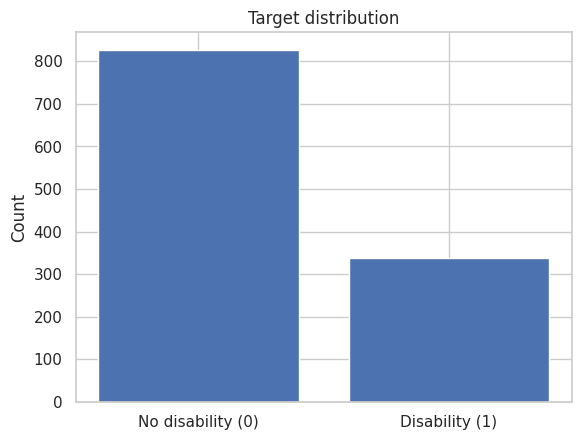

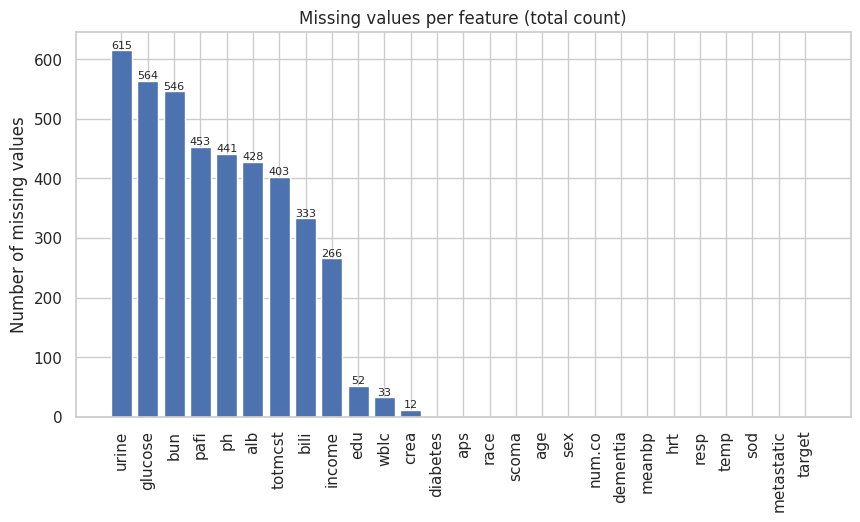

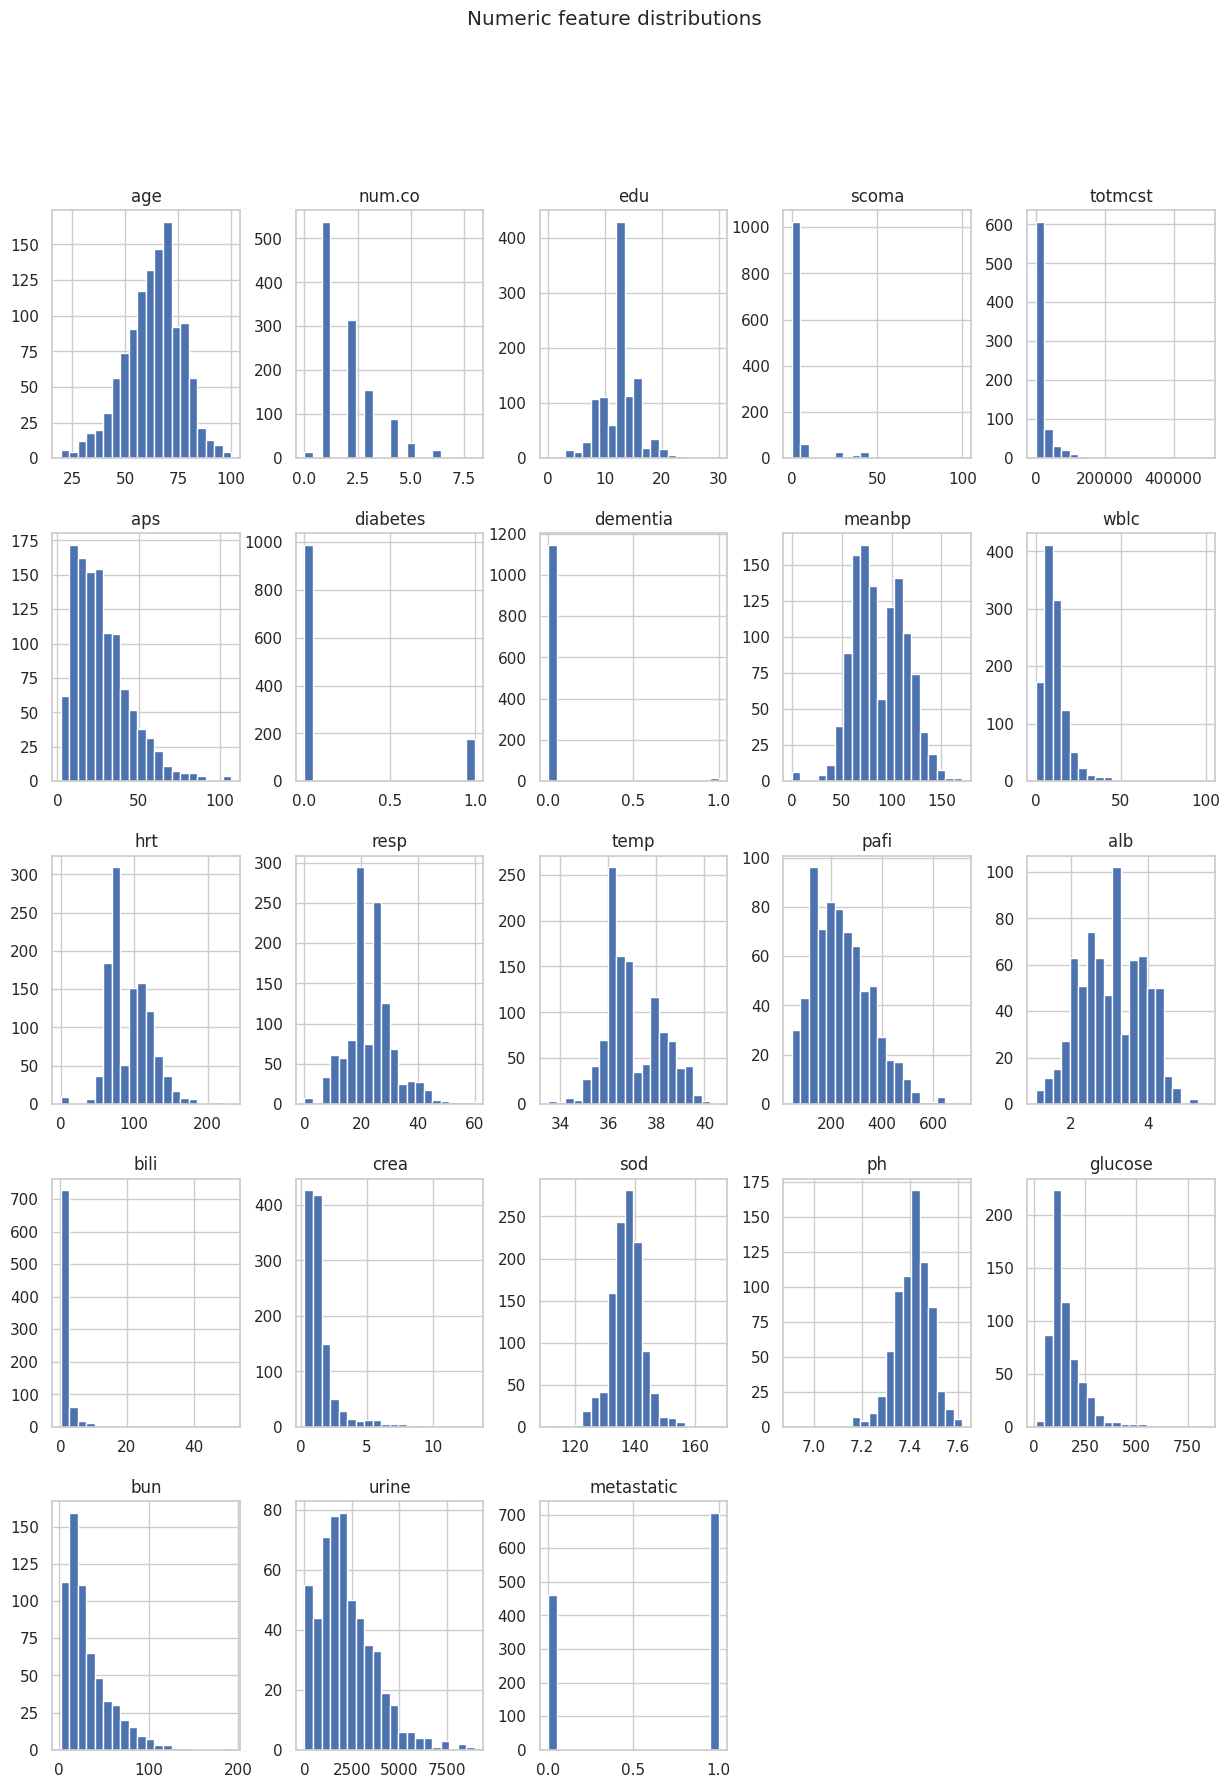

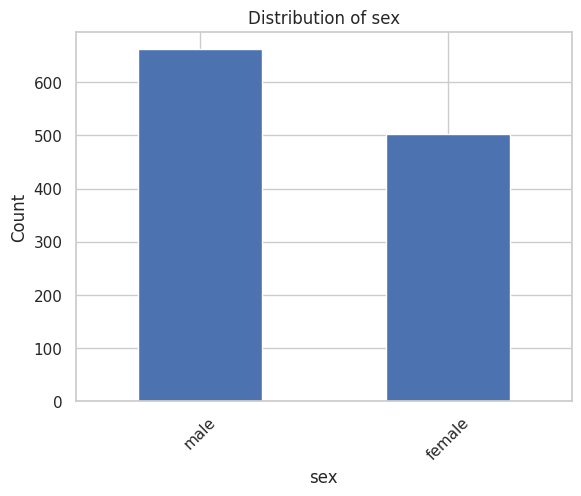

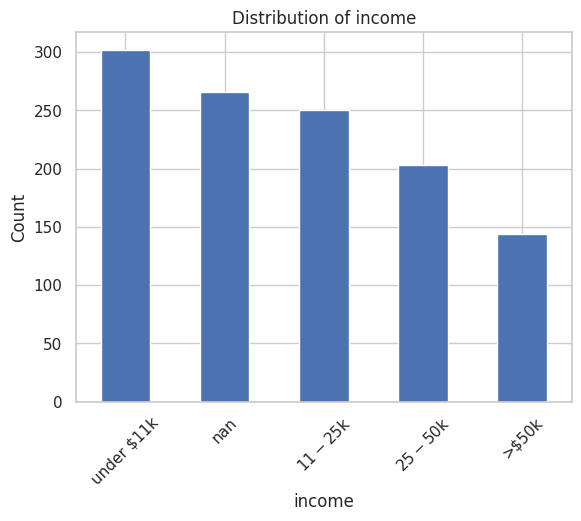

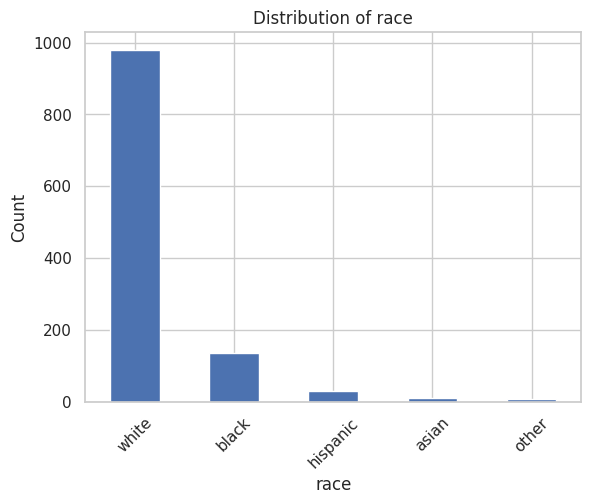

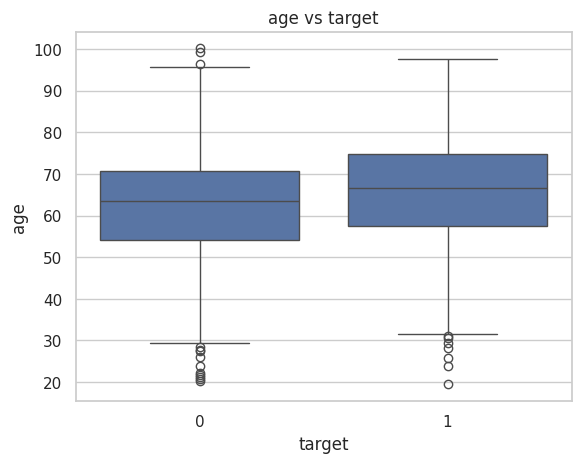

In [ ]:
# =========================================================
# 1. TARGET DISTRIBUTION
# =========================================================

plt.figure()
counts = train_df['target'].value_counts().sort_index()
plt.bar(['No disability (0)', 'Disability (1)'], counts.values)
plt.title('Target distribution')
plt.ylabel('Count')
plt.show()


# =========================================================
# 2. MISSING VALUES (IMPORTANT DATA QUALITY CHECK)
# =========================================================

missing_counts = train_df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(missing_counts.index, missing_counts.values)

plt.xticks(rotation=90)
plt.title('Missing values per feature (total count)')
plt.ylabel('Number of missing values')

# add labels on top of bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 str(int(height)),
                 ha='center', va='bottom', fontsize=8)

plt.show()


# =========================================================
# 3. NUMERIC FEATURE DISTRIBUTIONS
# =========================================================

num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.drop('target')

train_df[num_cols].hist(bins=20, figsize=(15, 20))
plt.suptitle("Numeric feature distributions")
plt.show()


# =========================================================
# 4. CATEGORICAL FEATURE DISTRIBUTIONS (TOP FEATURES ONLY)
# =========================================================

cat_cols = train_df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols[:10]:  # limit to avoid clutter
    plt.figure()
    train_df[col].value_counts(dropna=False).head(10).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Count')
    plt.show()


# =========================================================
# 5. TARGET VS KEY NUMERIC FEATURES (sanity check)
# =========================================================

key_features = [c for c in ['age'] if c in train_df.columns]

for col in key_features:
    plt.figure()
    sns.boxplot(x='target', y=col, data=train_df)
    plt.title(f'{col} vs target')
    plt.show()

In [ ]:
# =========================================================
# REMOVE FEATURES WITH > 30% MISSING VALUES
# =========================================================

missing_ratio = train_df.isna().mean()

# Identify columns to drop
cols_to_drop = missing_ratio[missing_ratio > 0.30].index.tolist()

print("\nColumns to remove (>30% missing):")
print(cols_to_drop)

# Drop them
final_df_reduced = train_df.drop(columns=cols_to_drop)

print("\nNew dataset shape after removing high-missing columns:")
print(final_df_reduced.shape)

print("\nRemaining columns:")
print(final_df_reduced.columns.tolist())


Columns to remove (>30% missing):
['totmcst', 'pafi', 'alb', 'ph', 'glucose', 'bun', 'urine']

New dataset shape after removing high-missing columns:
(1165, 20)

Remaining columns:
['age', 'sex', 'num.co', 'edu', 'income', 'scoma', 'race', 'aps', 'diabetes', 'dementia', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'bili', 'crea', 'sod', 'metastatic', 'target']


In [ ]:
# =========================================================
# GOWER DISTANCE DONOR IMPUTATION FOR 'income'
# =========================================================

# ---------------------------------------------------------
# FEATURES USED FOR MATCHING
# ---------------------------------------------------------

match_cols = [
    'age',
    'sex',
    'edu',
    'race'
]

target_col = 'income'

# ---------------------------------------------------------
# CREATE WORKING COPY
# ---------------------------------------------------------

df_imp = final_df_reduced.copy()

# ---------------------------------------------------------
# OPTIONAL: CLEAN CATEGORICAL VARIABLES
# ---------------------------------------------------------

for col in ['sex', 'edu', 'race', 'income']:
    df_imp[col] = df_imp[col].astype(str)

# Replace fake missing strings if present
df_imp.replace(['nan', 'None', 'missing'], np.nan, inplace=True)

# ---------------------------------------------------------
# SPLIT KNOWN VS MISSING INCOME
# ---------------------------------------------------------

known_df = df_imp[df_imp[target_col].notna()].copy()
missing_df = df_imp[df_imp[target_col].isna()].copy()

print("\nKnown income rows:", known_df.shape[0])
print("Missing income rows:", missing_df.shape[0])

# ---------------------------------------------------------
# COMPUTE GOWER DISTANCE MATRIX
# ---------------------------------------------------------

distance_matrix = gower.gower_matrix(
    missing_df[match_cols],
    known_df[match_cols]
)

print("\nDistance matrix shape:")
print(distance_matrix.shape)

# ---------------------------------------------------------
# GREEDY NEAREST-NEIGHBOR MATCHING
# WITH REPLACEMENT
# ---------------------------------------------------------

nearest_neighbor_idx = distance_matrix.argmin(axis=1)

# Get donor income values
donor_income = known_df.iloc[
    nearest_neighbor_idx
][target_col].values

# ---------------------------------------------------------
# IMPUTE MISSING VALUES
# ---------------------------------------------------------

df_imp.loc[
    df_imp[target_col].isna(),
    target_col
] = donor_income


# ---------------------------------------------------------
# CHECK RESULTS
# ---------------------------------------------------------

print("\nRemaining missing income values:")
print(df_imp['income'].isna().sum())

print("\nIncome distribution after imputation:")
print(df_imp['income'].value_counts())



Known income rows: 899
Missing income rows: 266

Distance matrix shape:
(266, 899)

Remaining missing income values:
0

Income distribution after imputation:
income
under $11k    394
$11-$25k      327
$25-$50k      250
>$50k         194
Name: count, dtype: int64


In [ ]:
# =========================================================
# CUSTOM IMPUTATION FUNCTION
# =========================================================

def custom_imputation_fit(df_imp):

    imputation_dict = {}

    # -----------------------------------------------------
    # MODE IMPUTATIONS
    # -----------------------------------------------------

    if 'edu' in df_imp.columns:

        imputation_dict['edu_mode'] = (
            df_imp['edu']
            .mode(dropna=True)[0]
        )

    if 'avtisst' in df_imp.columns:

        imputation_dict['avtisst_mode'] = (
            df_imp['avtisst']
            .mode(dropna=True)[0]
        )

    if 'charges' in df_imp.columns:

        imputation_dict['charges_mode'] = (
            df_imp['charges']
            .mode(dropna=True)[0]
        )

    # -----------------------------------------------------
    # FIXED VALUES
    # -----------------------------------------------------

    if 'wblc' in df_imp.columns:
        imputation_dict['wblc_value'] = 9

    if 'crea' in df_imp.columns:
        imputation_dict['crea_value'] = 1.01

    if 'dnr' in df_imp.columns:
        imputation_dict['dnr_value'] = 0

    if 'bili' in df_imp.columns:
        imputation_dict['bili_value'] = 1.01

    return imputation_dict


# =========================================================
# APPLY IMPUTATION FUNCTION
# =========================================================

def custom_imputation_transform(df, imputation_dict):

    df_imputed = df.copy()

    # -----------------------------------------------------
    # EDU
    # -----------------------------------------------------

    if (
        'edu' in df_imputed.columns
        and 'edu_mode' in imputation_dict
    ):

        df_imputed['edu'] = (
            df_imputed['edu']
            .fillna(imputation_dict['edu_mode'])
        )

    # -----------------------------------------------------
    # WBLC
    # -----------------------------------------------------

    if (
        'wblc' in df_imputed.columns
        and 'wblc_value' in imputation_dict
    ):

        df_imputed['wblc'] = (
            df_imputed['wblc']
            .fillna(imputation_dict['wblc_value'])
        )

    # -----------------------------------------------------
    # AVTISST
    # -----------------------------------------------------

    if (
        'avtisst' in df_imputed.columns
        and 'avtisst_mode' in imputation_dict
    ):

        df_imputed['avtisst'] = (
            df_imputed['avtisst']
            .fillna(imputation_dict['avtisst_mode'])
        )

    # -----------------------------------------------------
    # CHARGES
    # -----------------------------------------------------

    if (
        'charges' in df_imputed.columns
        and 'charges_mode' in imputation_dict
    ):

        df_imputed['charges'] = (
            df_imputed['charges']
            .fillna(imputation_dict['charges_mode'])
        )

    # -----------------------------------------------------
    # CREA
    # -----------------------------------------------------

    if (
        'crea' in df_imputed.columns
        and 'crea_value' in imputation_dict
    ):

        df_imputed['crea'] = (
            df_imputed['crea']
            .fillna(imputation_dict['crea_value'])
        )

    # -----------------------------------------------------
    # DNR
    # -----------------------------------------------------

    if (
        'dnr' in df_imputed.columns
        and 'dnr_value' in imputation_dict
    ):

        df_imputed['dnr'] = (
            df_imputed['dnr']
            .fillna(imputation_dict['dnr_value'])
        )

    # -----------------------------------------------------
    # BILI
    # -----------------------------------------------------

    if (
        'bili' in df_imputed.columns
        and 'bili_value' in imputation_dict
    ):

        df_imputed['bili'] = (
            df_imputed['bili']
            .fillna(imputation_dict['bili_value'])
        )

    return df_imputed

In [ ]:
# =========================================================
# PREPROCESSING FUNCTIONS
# =========================================================

# =========================================================
# FIT PREPROCESSOR
# =========================================================

def preprocessing_fit(train_df):

    preprocess_dict = {}

    # -----------------------------------------------------
    # FEATURES TO STANDARDIZE
    # -----------------------------------------------------

    scale_cols = [
        'age',
        'num.co',
        'edu',
        'scoma',
        'charges',
        'avtisst',
        'aps',
        'meanbp',
        'wblc',
        'hrt',
        'resp',
        'temp',
        'crea',
        'sod'
    ]

    # KEEP ONLY EXISTING COLUMNS
    scale_cols = [
        col for col in scale_cols
        if col in train_df.columns
    ]

    preprocess_dict['scale_cols'] = scale_cols

    # -----------------------------------------------------
    # FIT SCALERS
    # -----------------------------------------------------

    scalers = {}

    for col in scale_cols:

        scaler = StandardScaler()

        scaler.fit(
            train_df[[col]]
        )

        scalers[col] = scaler

    preprocess_dict['scalers'] = scalers

    # -----------------------------------------------------
    # STORE CATEGORIES
    # -----------------------------------------------------

    if 'race' in train_df.columns:

        preprocess_dict['race_categories'] = sorted(
            train_df['race']
            .dropna()
            .unique()
        )

    if 'income' in train_df.columns:

        preprocess_dict['income_categories'] = sorted(
            train_df['income']
            .dropna()
            .unique()
        )

    return preprocess_dict


# =========================================================
# APPLY PREPROCESSING
# =========================================================

def preprocessing_transform(df, preprocess_dict):

    df_proc = df.copy()

    # -----------------------------------------------------
    # SEX BINARIZATION
    # -----------------------------------------------------

    if 'sex' in df_proc.columns:

        sex_mapping = {
            'male': 0,
            'female': 1
        }

        df_proc['sex'] = (
            df_proc['sex']
            .map(sex_mapping)
        )

    # -----------------------------------------------------
    # RACE OHE
    # -----------------------------------------------------

    if 'race' in df_proc.columns:

        race_cat_type = pd.CategoricalDtype(
            categories=preprocess_dict['race_categories']
        )

        df_proc['race'] = (
            df_proc['race']
            .astype(race_cat_type)
        )

        race_dummies = pd.get_dummies(
            df_proc['race'],
            prefix='race',
            drop_first=True
        )

        df_proc = pd.concat(
            [df_proc, race_dummies],
            axis=1
        )

        df_proc.drop(
            columns=['race'],
            inplace=True
        )

    # -----------------------------------------------------
    # INCOME OHE
    # -----------------------------------------------------

    if 'income' in df_proc.columns:

        income_cat_type = pd.CategoricalDtype(
            categories=preprocess_dict['income_categories']
        )

        df_proc['income'] = (
            df_proc['income']
            .astype(income_cat_type)
        )

        income_dummies = pd.get_dummies(
            df_proc['income'],
            prefix='income',
            drop_first=False
        )

        df_proc = pd.concat(
            [df_proc, income_dummies],
            axis=1
        )

        df_proc.drop(
            columns=['income'],
            inplace=True
        )

    # -----------------------------------------------------
    # STANDARDIZATION
    # -----------------------------------------------------

    for col in preprocess_dict['scale_cols']:

        if col in df_proc.columns:

            scaler = preprocess_dict['scalers'][col]

            df_proc[col] = scaler.transform(
                df_proc[[col]]
            ).flatten()

    # -----------------------------------------------------
    # ENSURE NUMERIC
    # -----------------------------------------------------

    df_proc = df_proc.apply(
        pd.to_numeric,
        errors='ignore'
    )

    return df_proc

### Variance Filtering and Correlation Matrix


Initial shape:
(1165, 20)

Remaining missing values after imputation:
Series([], dtype: int64)

Final remaining NaNs:
Series([], dtype: int64)

Dtypes:
age                  float64
sex                    int64
num.co               float64
edu                  float64
scoma                float64
aps                  float64
diabetes               int64
dementia               int64
meanbp               float64
wblc                 float64
hrt                  float64
resp                 float64
temp                 float64
bili                 float64
crea                 float64
sod                  float64
metastatic             int64
race_black              bool
race_hispanic           bool
race_other              bool
race_white              bool
income_$11-$25k         bool
income_$25-$50k         bool
income_>$50k            bool
income_under $11k       bool
dtype: object

Feature variances:
              feature  variance
19         race_other  0.007672
7            dementia  0

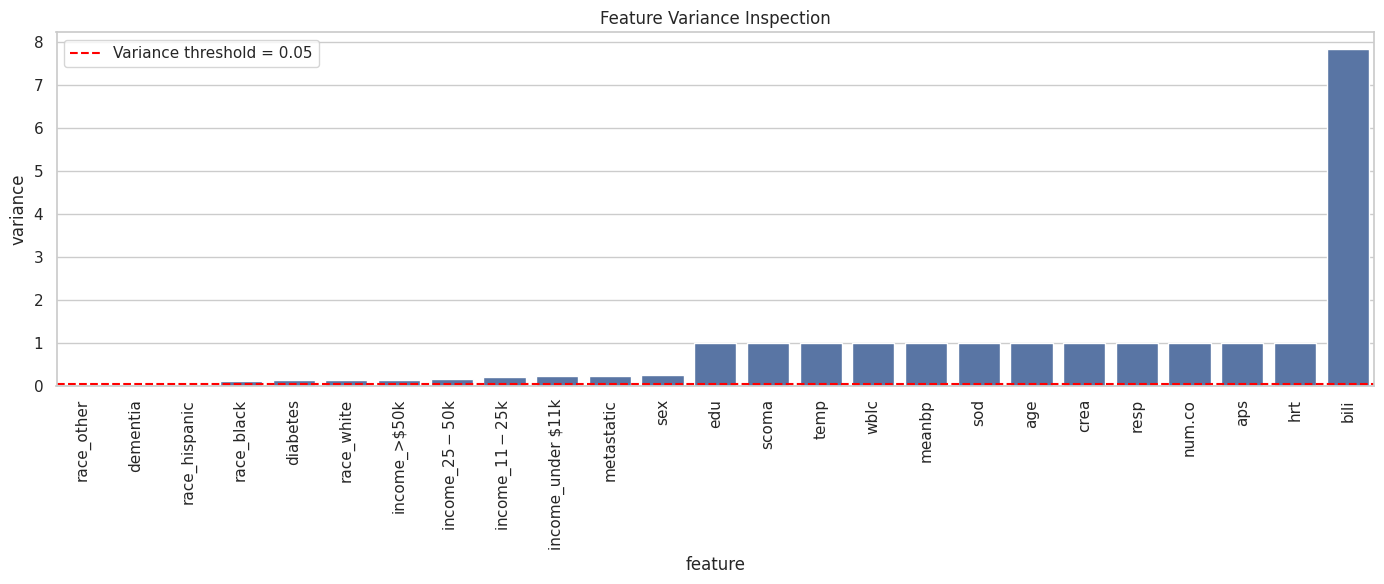


Removed low-variance features:
['dementia', 'race_hispanic', 'race_other']

Shape after variance filtering:
(1165, 22)


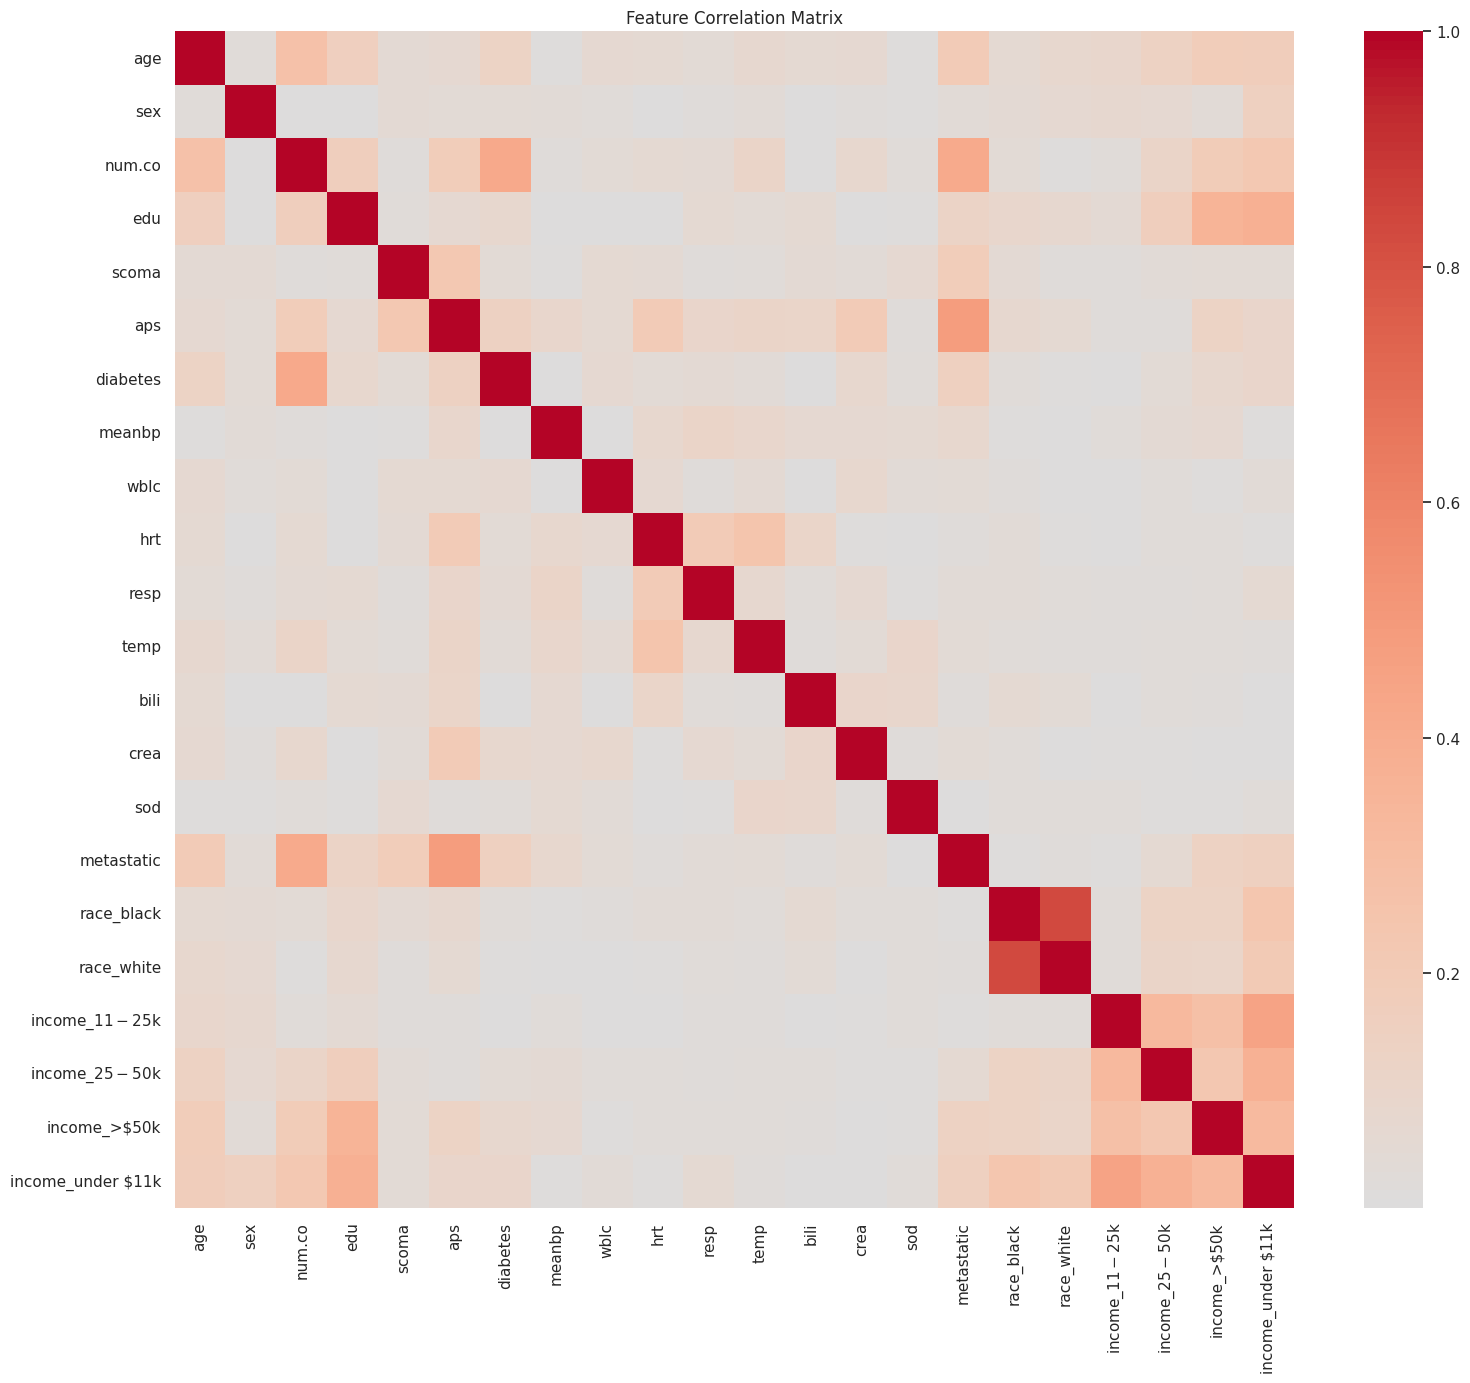


Highly correlated feature pairs (>0.90):


Features to remove due to high correlation:
[]

Final selected feature shape:
(1165, 22)

Final selected features:
['age', 'sex', 'num.co', 'edu', 'scoma', 'aps', 'diabetes', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'bili', 'crea', 'sod', 'metastatic', 'race_black', 'race_white', 'income_$11-$25k', 'income_$25-$50k', 'income_>$50k', 'income_under $11k']


In [ ]:
# =========================================================
# EXPLORATORY PREPROCESSING PIPELINE
# ONLY FOR FEATURE INSPECTION
# =========================================================

# IMPORTANT:
# This does NOT overwrite your original df_imp.
# We create a fully separate copy only for:
# - variance threshold inspection
# - correlation inspection
#
# Your original df_imp will remain:
# - raw
# - non-preprocessed
# - with missing values
#
# and will later be used correctly inside nested CV.
# =========================================================

# =========================================================
# CREATE SAFE COPY
# =========================================================

df_visual = df_imp.copy()

print("\nInitial shape:")
print(df_visual.shape)

# =========================================================
# APPLY CUSTOM IMPUTATION
# =========================================================

imputation_dict = custom_imputation_fit(df_visual)

df_visual = custom_imputation_transform(
    df_visual,
    imputation_dict
)

# =========================================================
# CHECK REMAINING MISSING VALUES
# =========================================================

print("\nRemaining missing values after imputation:")

remaining_missing = (
    df_visual
    .isna()
    .sum()
)

print(
    remaining_missing[
        remaining_missing > 0
    ]
)

# =========================================================
# APPLY PREPROCESSING
# =========================================================

preprocess_dict = preprocessing_fit(df_visual)

df_visual = preprocessing_transform(
    df_visual,
    preprocess_dict
)

# =========================================================
# REMOVE TARGET
# =========================================================

target_col = 'target'

X_visual = df_visual.drop(
    columns=[target_col]
).copy()

# =========================================================
# FORCE NUMERIC
# =========================================================

X_visual = X_visual.apply(
    pd.to_numeric,
    errors='coerce'
)

# =========================================================
# FINAL NaN CHECK
# =========================================================

print("\nFinal remaining NaNs:")

print(
    X_visual
    .isna()
    .sum()[
        X_visual.isna().sum() > 0
    ]
)

# =========================================================
# FINAL DTYPE CHECK
# =========================================================

print("\nDtypes:")

print(X_visual.dtypes)

# =========================================================
# CONVERT EVERYTHING TO FLOAT
# IMPORTANT FOR CONSISTENCY
# =========================================================

X_visual = X_visual.astype(float)

# =========================================================
# FEATURE VARIANCES
# =========================================================

variances = X_visual.var()

variance_df = pd.DataFrame({
    'feature': variances.index,
    'variance': variances.values
})

variance_df = variance_df.sort_values(
    by='variance'
)

print("\nFeature variances:")
print(variance_df)

# =========================================================
# PLOT VARIANCES
# =========================================================

plt.figure(figsize=(14,6))

sns.barplot(
    data=variance_df,
    x='feature',
    y='variance'
)

plt.xticks(rotation=90)

plt.axhline(
    y=0.05,
    color='red',
    linestyle='--',
    label='Variance threshold = 0.05'
)

plt.title('Feature Variance Inspection')

plt.legend()

plt.tight_layout()
plt.show()

# =========================================================
# APPLY VARIANCE THRESHOLD
# =========================================================

selector = VarianceThreshold(
    threshold=0.05
)

selector.fit(X_visual)

selected_features = X_visual.columns[
    selector.get_support()
]

removed_low_variance = [
    c for c in X_visual.columns
    if c not in selected_features
]

print("\nRemoved low-variance features:")
print(removed_low_variance)

# =========================================================
# DATA AFTER VARIANCE FILTER
# =========================================================

X_var = X_visual[
    selected_features
].copy()

print("\nShape after variance filtering:")
print(X_var.shape)

# =========================================================
# CORRELATION MATRIX
# =========================================================

corr_matrix = X_var.corr().abs()

# =========================================================
# HEATMAP
# =========================================================

plt.figure(figsize=(16,14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

# =========================================================
# FIND HIGHLY CORRELATED FEATURES
# =========================================================

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = []

for col in upper_triangle.columns:

    correlated = upper_triangle[col][
        upper_triangle[col] > 0.90
    ]

    for idx, value in correlated.items():

        high_corr_pairs.append(
            (idx, col, value)
        )

# =========================================================
# PRINT CORRELATED PAIRS
# =========================================================

print("\nHighly correlated feature pairs (>0.90):\n")

for feat1, feat2, corr_val in high_corr_pairs:

    print(
        f"{feat1} <--> {feat2} | corr = {corr_val:.3f}"
    )

# =========================================================
# REMOVE ONE FEATURE PER CORRELATED PAIR
# =========================================================

to_drop_corr = set()

for feat1, feat2, corr_val in high_corr_pairs:

    # simple rule:
    # remove second feature

    to_drop_corr.add(feat2)

print("\nFeatures to remove due to high correlation:")
print(list(to_drop_corr))

# =========================================================
# FINAL FEATURE SET
# =========================================================

X_selected = X_var.drop(
    columns=list(to_drop_corr),
    errors='ignore'
)

print("\nFinal selected feature shape:")
print(X_selected.shape)

print("\nFinal selected features:")
print(X_selected.columns.tolist())

In [ ]:
# =========================================================
# REMOVE 'dementia' FROM RAW DATASET
# BEFORE NESTED CV
# =========================================================

df_cv = df_imp.copy()

# Remove feature
df_cv = df_cv.drop(
    columns=['dementia'],
    errors='ignore'
)

print("\nUpdated dataset shape:")
print(df_cv.shape)

print("\nRemaining features:")
print(df_cv.columns.tolist())


Updated dataset shape:
(1165, 19)

Remaining features:
['age', 'sex', 'num.co', 'edu', 'income', 'scoma', 'race', 'aps', 'diabetes', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'bili', 'crea', 'sod', 'metastatic', 'target']


---
## Phase 2: Model Training

In [ ]:
# =========================================================
# MODELS + PARAMETER GRIDS
# =========================================================

models = {

    'LogisticRegression': {
        'model': LogisticRegression(
            max_iter=5000,
            random_state=42
        ),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'class_weight': [None, 'balanced']
        }
    },

    'DecisionTree': {
        'model': DecisionTreeClassifier(
            random_state=42
        ),
        'params': {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5],
            'class_weight': [None, 'balanced']
        }
    },

    'RandomForest': {
        'model': RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'class_weight': [None, 'balanced']
        }
    },

    'XGBoost': {
        'model': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.8, 1.0]
        }
    }
}



## a. Baseline Model

In [ ]:
# =========================================================
# NESTED CV FUNCTION
# =========================================================

def nested_cv_evaluation(
    df_cv,
    target_col='target',
    outer_splits=5,
    inner_splits=5
):

    # -----------------------------------------------------
    # STORE RESULTS
    # -----------------------------------------------------

    all_results = []

    # -----------------------------------------------------
    # SPLIT FEATURES / TARGET
    # -----------------------------------------------------

    X = df_cv.drop(columns=[target_col])
    y = df_cv[target_col]

    # -----------------------------------------------------
    # OUTER CV
    # -----------------------------------------------------

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=42
    )

    # -----------------------------------------------------
    # LOOP OVER MODELS
    # -----------------------------------------------------

    for model_name, model_info in models.items():

        print("\n================================================")
        print(f"MODEL: {model_name}")
        print("================================================")

        outer_fold = 1

        fold_metrics = []

        # -------------------------------------------------
        # OUTER LOOP
        # -------------------------------------------------

        for train_idx, valid_idx in outer_cv.split(X, y):

            print(f"\nOuter Fold {outer_fold}")

            # ---------------------------------------------
            # SPLIT FOLD
            # ---------------------------------------------

            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y.iloc[train_idx].copy()

            X_valid_fold = X.iloc[valid_idx].copy()
            y_valid_fold = y.iloc[valid_idx].copy()

            # ---------------------------------------------
            # REBUILD DATAFRAMES
            # ---------------------------------------------

            train_fold = X_train_fold.copy()
            train_fold[target_col] = y_train_fold.values

            valid_fold = X_valid_fold.copy()
            valid_fold[target_col] = y_valid_fold.values

            # =============================================
            # IMPUTATION
            # FIT ONLY ON TRAIN FOLD
            # =============================================

            imputation_dict = custom_imputation_fit(
                train_fold
            )

            train_fold = custom_imputation_transform(
                train_fold,
                imputation_dict
            )

            valid_fold = custom_imputation_transform(
                valid_fold,
                imputation_dict
            )

            # =============================================
            # PREPROCESSING
            # FIT ONLY ON TRAIN FOLD
            # =============================================

            preprocess_dict = preprocessing_fit(
                train_fold
            )

            train_fold = preprocessing_transform(
                train_fold,
                preprocess_dict
            )

            valid_fold = preprocessing_transform(
                valid_fold,
                preprocess_dict
            )

            # =============================================
            # SPLIT AGAIN
            # =============================================

            X_train_proc = train_fold.drop(columns=[target_col])
            y_train_proc = train_fold[target_col]

            X_valid_proc = valid_fold.drop(columns=[target_col])
            y_valid_proc = valid_fold[target_col]

            # =============================================
            # BALANCING
            # =============================================

            counter = Counter(y_train_proc)

            print("\nOriginal distribution:")
            print(counter)

            # ---------------------------------------------
            # SLIGHT UNDERSAMPLING
            # minority / majority = 0.67
            # (~40/60 ratio)
            # ---------------------------------------------

            under = RandomUnderSampler(
                sampling_strategy=0.67,
                random_state=42
            )

            # ---------------------------------------------
            # SMOTE OVERSAMPLING
            # ---------------------------------------------

            smote = SMOTE(
                random_state=42
            )

            # =============================================
            # INNER CV GRID SEARCH
            # =============================================

            pipeline = ImbPipeline([
                ('under', under),
                ('smote', smote),
                ('model', model_info['model'])
            ])

            param_grid = {
                f'model__{k}': v
                for k, v in model_info['params'].items()
            }

            inner_cv = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=42
            )

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=-1,
                verbose=0,
                error_score='raise'
            )

            # =========================================================
            # CONVERT ALL FEATURES TO FLOAT
            # =========================================================

            X_train_proc = X_train_proc.astype(float)
            X_valid_proc = X_valid_proc.astype(float)

            # =============================================
            # FIT GRID SEARCH
            # =============================================

            grid.fit(
                X_train_proc,
                y_train_proc
            )

            best_model = grid.best_estimator_

            # =============================================
            # PROBABILITÀ E RICERCA SOGLIA (YOUDEN J)
            # =============================================

            # Calcoliamo prima le probabilità
            y_train_proba = best_model.predict_proba(X_train_proc)[:,1]
            y_valid_proba = best_model.predict_proba(X_valid_proc)[:,1]

            # Troviamo la soglia ottimale sul TRAIN (per evitare data leakage)
            fpr, tpr, thresholds = roc_curve(y_train_proc, y_train_proba)
            youden_j = tpr - fpr
            best_threshold = thresholds[np.argmax(youden_j)]

            print(f"Soglia ottimale Youden per Fold {outer_fold}: {best_threshold:.4f}")

            # Creiamo le PREDIZIONI finali (0 o 1) basate sulla nuova soglia
            y_train_pred = (y_train_proba >= best_threshold).astype(int)
            y_valid_pred = (y_valid_proba >= best_threshold).astype(int)

            # =============================================
            # METRICS
            # =============================================

            metrics_dict = {

                'model': model_name,
                'outer_fold': outer_fold,



                # =========================================
                # TRAIN METRICS
                # =========================================

                'train_accuracy':
                    accuracy_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_auc':
                    roc_auc_score(
                        y_train_proc,
                        y_train_proba
                    ),

                'train_f1':
                    f1_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_precision':
                    precision_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_recall':
                    recall_score(
                        y_train_proc,
                        y_train_pred
                    ),

                # =========================================
                # VALIDATION METRICS
                # =========================================

                'valid_accuracy':
                    accuracy_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_auc':
                    roc_auc_score(
                        y_valid_proc,
                        y_valid_proba
                    ),

                'valid_f1':
                    f1_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_precision':
                    precision_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_recall':
                    recall_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                # =========================================
                # STORE PREDICTIONS
                # =========================================

                'y_true':
                    list(y_valid_proc),

                'y_pred':
                    list(y_valid_pred),

                'y_proba':
                    list(y_valid_proba),

                # =========================================
                # STORE OBJECTS FOR SHAP
                # =========================================

                'best_model':
                    best_model,

                'X_valid':
                    X_valid_proc,

                'feature_names':
                    X_valid_proc.columns.tolist(),





                # =========================================
                # BEST PARAMETERS
                # =========================================

                'best_params':
                    grid.best_params_
            }

            # =============================================
            # SAVE RESULTS
            # =============================================

            fold_metrics.append(metrics_dict)

            print(
                f"Validation AUC: "
                f"{metrics_dict['valid_auc']:.4f}"
            )

            outer_fold += 1

        # -------------------------------------------------
        # SAVE MODEL RESULTS
        # -------------------------------------------------

        model_results = pd.DataFrame(fold_metrics)

        all_results.append(model_results)

    # -----------------------------------------------------
    # CONCATENATE RESULTS
    # -----------------------------------------------------

    final_results = pd.concat(
        all_results,
        axis=0
    )

    return final_results

runtime: 9 min

In [ ]:
results_df = nested_cv_evaluation(
    df_cv=df_cv,
    target_col='target',
    outer_splits=5,
    inner_splits=5
)


MODEL: LogisticRegression

Outer Fold 1

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 1: 0.4952
Validation AUC: 0.6310

Outer Fold 2

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 2: 0.4882
Validation AUC: 0.6449

Outer Fold 3

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 3: 0.4995
Validation AUC: 0.6346

Outer Fold 4

Original distribution:
Counter({0: 661, 1: 271})
Soglia ottimale Youden per Fold 4: 0.4790
Validation AUC: 0.6019

Outer Fold 5

Original distribution:
Counter({0: 661, 1: 271})
Soglia ottimale Youden per Fold 5: 0.4658
Validation AUC: 0.6847

MODEL: DecisionTree

Outer Fold 1

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 1: 0.3333
Validation AUC: 0.5682

Outer Fold 2

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 2: 0.5289
Validation AUC: 0.6441

Outer Fold 3

Original distribution:
Counter({0:

In [ ]:
# =========================================================
# METRICS TO SUMMARIZE
# =========================================================

metrics_cols = [
    'train_accuracy',
    'train_auc',
    'train_f1',
    'train_precision',
    'train_recall',
    'valid_accuracy',
    'valid_auc',
    'valid_f1',
    'valid_precision',
    'valid_recall'
]

# =========================================================
# COMPUTE MEAN
# =========================================================

mean_df = results_df.groupby('model')[metrics_cols].mean()

# =========================================================
# COMPUTE STANDARD DEVIATION
# =========================================================

std_df = results_df.groupby('model')[metrics_cols].std()

# =========================================================
# CREATE COMBINED TABLE
# =========================================================

summary_table = mean_df.copy()

for col in metrics_cols:

    summary_table[col] = (
        mean_df[col].round(3).astype(str)
        + " ± "
        + std_df[col].round(3).astype(str)
    )

# =========================================================
# PRINT
# =========================================================

print(summary_table)

                   train_accuracy      train_auc       train_f1  \
model                                                             
DecisionTree        0.622 ± 0.035  0.675 ± 0.045  0.498 ± 0.038   
LogisticRegression  0.616 ± 0.021  0.668 ± 0.008  0.501 ± 0.017   
RandomForest        0.838 ± 0.098  0.907 ± 0.074  0.766 ± 0.135   
XGBoost             0.708 ± 0.015  0.771 ± 0.019  0.581 ± 0.016   

                   train_precision   train_recall valid_accuracy  \
model                                                              
DecisionTree         0.409 ± 0.023  0.658 ± 0.153  0.573 ± 0.067   
LogisticRegression   0.403 ± 0.014  0.666 ± 0.052  0.606 ± 0.028   
RandomForest         0.683 ± 0.163  0.882 ± 0.095  0.621 ± 0.043   
XGBoost                0.5 ± 0.019    0.7 ± 0.071  0.609 ± 0.039   

                        valid_auc       valid_f1 valid_precision  \
model                                                              
DecisionTree        0.592 ± 0.046  0.418 ± 0.057    

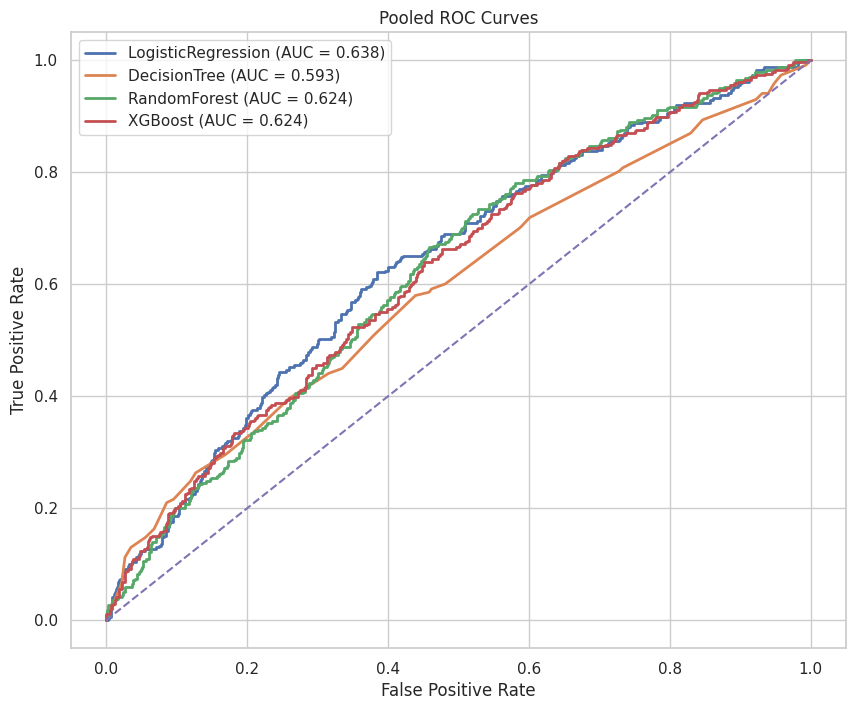

In [ ]:
# =====================================================
# POOLED ROC CURVES
# =====================================================

plt.figure(figsize=(10,8))

models_list = results_df['model'].unique()

for model_name in models_list:

    model_df = results_df[
        results_df['model'] == model_name
    ]

    # ---------------------------------------------
    # POOL PREDICTIONS ACROSS FOLDS
    # ---------------------------------------------

    y_true = np.concatenate(
        model_df['y_true'].values
    )

    y_proba = np.concatenate(
        model_df['y_proba'].values
    )

    # ---------------------------------------------
    # ROC
    # ---------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_true,
        y_proba
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Pooled ROC Curves')
plt.legend()
plt.grid(True)

plt.show()

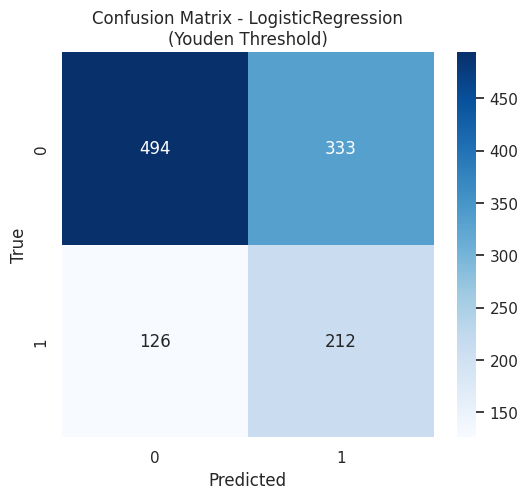

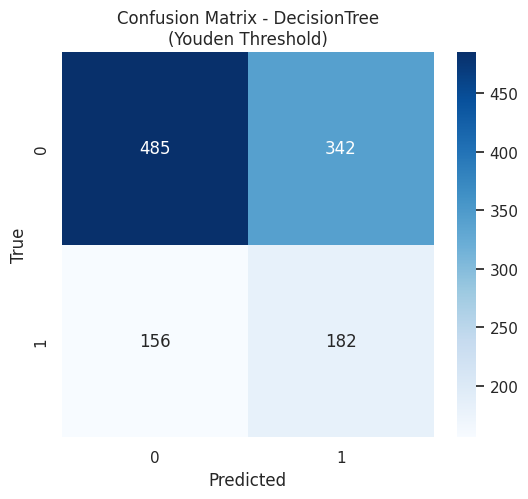

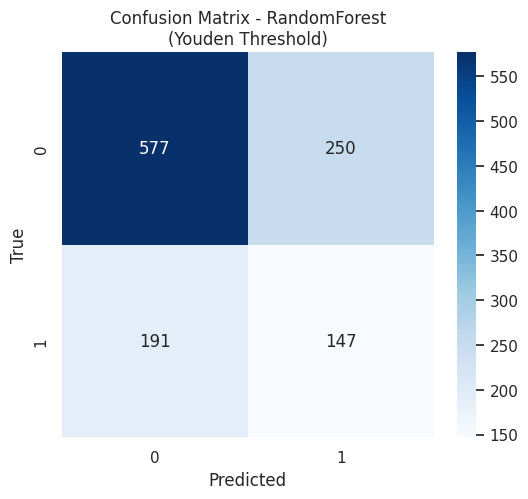

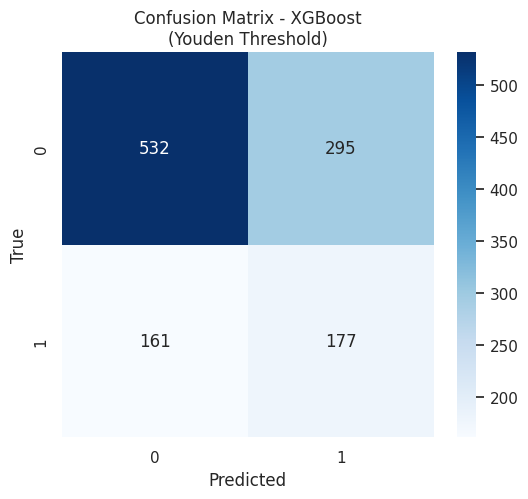

In [ ]:
# =====================================================
# CONFUSION MATRICES USING STORED YOUDEN PREDICTIONS
# =====================================================

for model_name in results_df['model'].unique():

    model_df = results_df[
        results_df['model'] == model_name
    ]

    # ---------------------------------------------
    # POOL FOLD PREDICTIONS
    # ---------------------------------------------

    y_true = np.concatenate(
        model_df['y_true'].values
    )

    # These predictions already use the
    # Youden threshold computed inside CV
    y_pred = np.concatenate(
        model_df['y_pred'].values
    )

    # ---------------------------------------------
    # CONFUSION MATRIX
    # ---------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # Optional: mean threshold across folds
    if 'best_threshold' in model_df.columns:
        mean_threshold = model_df[
            'best_threshold'
        ].mean()

        title = (
            f'Confusion Matrix - {model_name}\n'
            f'(Youden Threshold mean = {mean_threshold:.3f})'
        )
    else:
        title = (
            f'Confusion Matrix - {model_name}\n'
            f'(Youden Threshold)'
        )

    # ---------------------------------------------
    # PLOT
    # ---------------------------------------------

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)

    plt.xlabel('Predicted')
    plt.ylabel('True')

    plt.show()


SHAP ANALYSIS: LogisticRegression


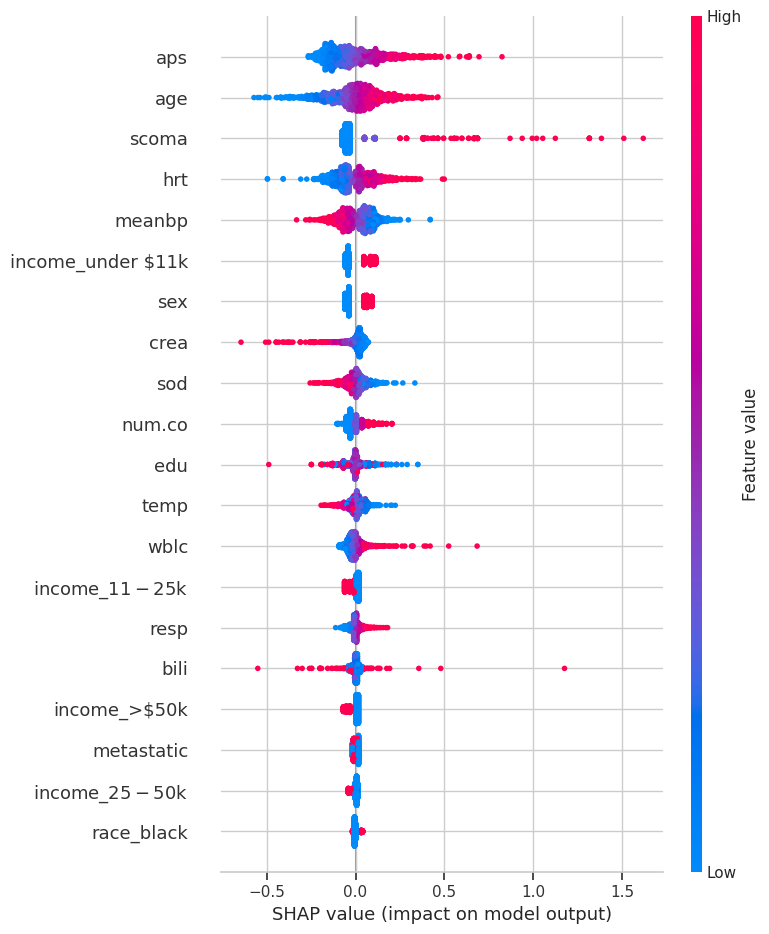


SHAP ANALYSIS: DecisionTree


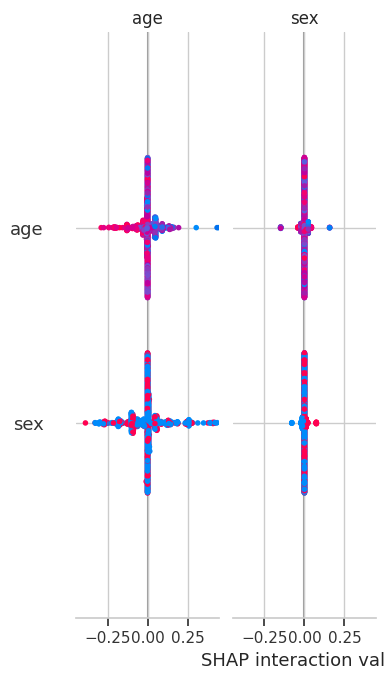


SHAP ANALYSIS: RandomForest


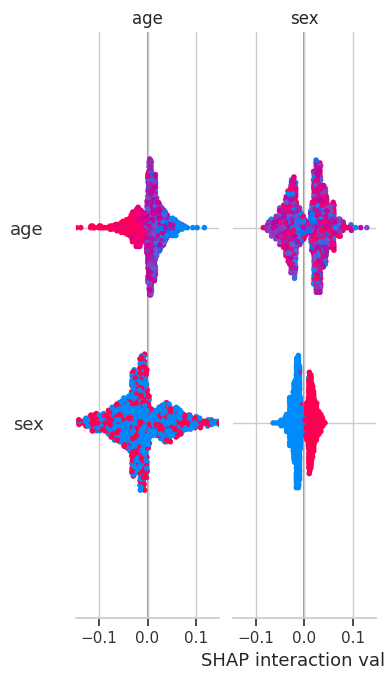


SHAP ANALYSIS: XGBoost


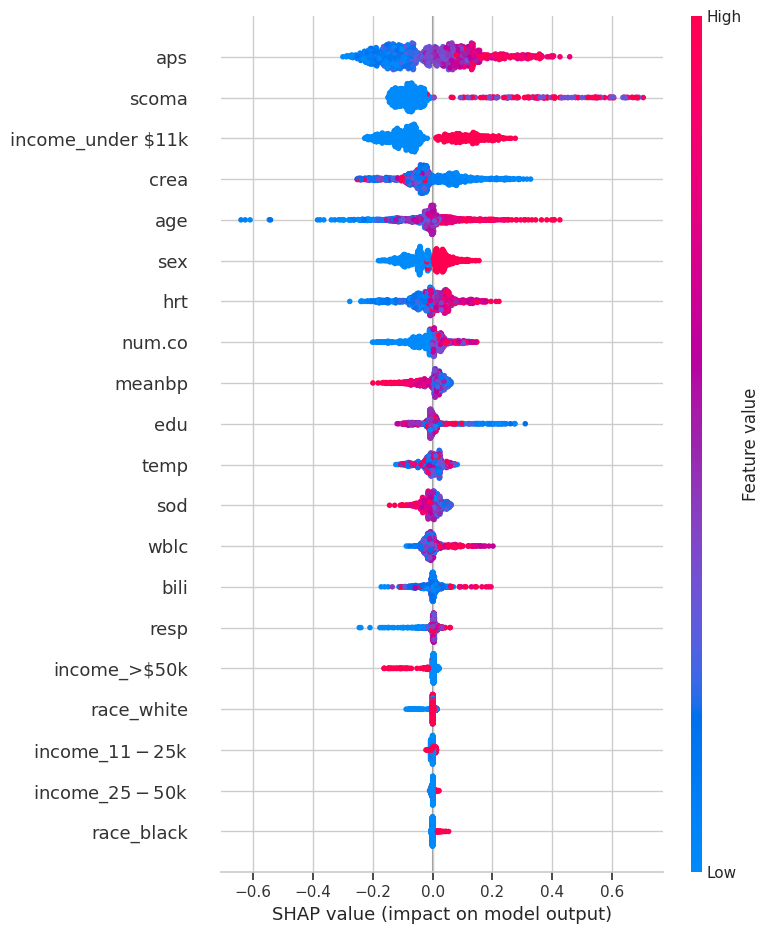

In [ ]:
# =====================================================
# SHAP VALUES FOR EACH MODEL
# =====================================================

import shap

for model_name in results_df['model'].unique():

    print("\n====================================")
    print(f"SHAP ANALYSIS: {model_name}")
    print("====================================")

    model_df = results_df[
        results_df['model'] == model_name
    ]

    shap_values_all = []
    X_all = []

    # -------------------------------------------------
    # LOOP OVER OUTER FOLDS
    # -------------------------------------------------

    for _, row in model_df.iterrows():

        best_model = row['best_model']
        X_valid = row['X_valid']

        # Extract trained classifier
        clf = best_model.named_steps['model']

        # ---------------------------------------------
        # SHAP EXPLAINER
        # ---------------------------------------------

        if model_name in ['DecisionTree', 'RandomForest', 'XGBoost']:

            explainer = shap.TreeExplainer(clf)

            shap_values = explainer.shap_values(X_valid)

            # Binary classification
            if isinstance(shap_values, list):
                shap_values = shap_values[1]

        else:
            explainer = shap.Explainer(
                clf,
                X_valid
            )

            shap_values = explainer(
                X_valid
            ).values

        shap_values_all.append(shap_values)
        X_all.append(X_valid)

    # -------------------------------------------------
    # CONCATENATE ALL FOLDS
    # -------------------------------------------------

    shap_values_all = np.vstack(
        shap_values_all
    )

    X_all = pd.concat(
        X_all,
        axis=0
    )

    # -------------------------------------------------
    # SUMMARY PLOT
    # -------------------------------------------------

    shap.summary_plot(
        shap_values_all,
        X_all,
        show=True
    )

### Inference on Test

Fitting 5 folds for each of 8 candidates, totalling 40 fits

BEST PARAMETERS
{'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l2'}

Best Youden Threshold: 0.5248

HELD-OUT TEST RESULTS
Accuracy : 0.6165
AUC      : 0.6244
F1 Score : 0.4234
Precision: 0.3766
Recall   : 0.4833


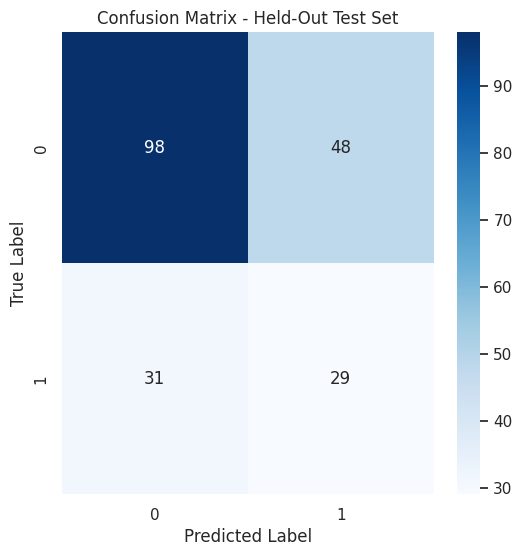

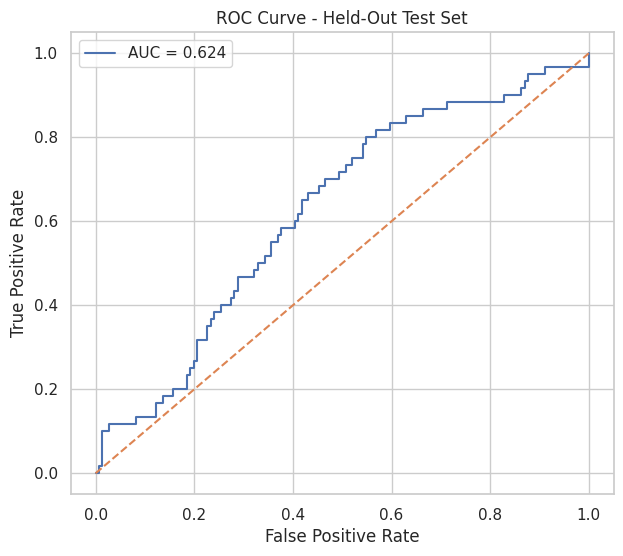

In [ ]:
# =========================================================
# LOAD TEST SET
# =========================================================

test_path = "support2_test.xlsx"

df_test = pd.read_excel(test_path)

target_col = "target"

# =========================================================
# TRAIN = df_cv
# TEST = held-out test set
# =========================================================

train_df = df_cv.copy()

# =========================================================
# IMPUTATION
# FIT ONLY ON TRAIN
# =========================================================

imputation_dict = custom_imputation_fit(
    train_df
)

train_df = custom_imputation_transform(
    train_df,
    imputation_dict
)

df_test = custom_imputation_transform(
    df_test,
    imputation_dict
)

# =========================================================
# PREPROCESSING
# FIT ONLY ON TRAIN
# =========================================================

preprocess_dict = preprocessing_fit(
    train_df
)

train_df = preprocessing_transform(
    train_df,
    preprocess_dict
)

df_test = preprocessing_transform(
    df_test,
    preprocess_dict
)

# =========================================================
# SPLIT FEATURES / TARGET
# =========================================================

X_train = train_df.drop(columns=[target_col]).astype(float)
y_train = train_df[target_col]

X_test = df_test.drop(columns=[target_col]).astype(float)
y_test = df_test[target_col]

# =========================================================
# BALANCING
# =========================================================

under = RandomUnderSampler(
    sampling_strategy=0.67,
    random_state=42
)

smote = SMOTE(
    random_state=42
)

# =========================================================
# LOGISTIC REGRESSION PIPELINE
# =========================================================

pipeline = ImbPipeline([

    ('under', under),

    ('smote', smote),

    ('model',
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

# =========================================================
# PARAM GRID
# =========================================================

param_grid = {

    'model__C': [0.01, 0.1, 1, 10],

    'model__penalty': ['l2'],

    'model__class_weight': [
        None,
        'balanced'
    ]
}

# =========================================================
# INNER CV FOR FINAL TUNING
# =========================================================

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# GRID SEARCH
# =========================================================

grid = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring='roc_auc',

    cv=inner_cv,

    n_jobs=-1,

    verbose=1
)

# =========================================================
# TRAIN FINAL MODEL ON ALL TRAINING DATA
# =========================================================

grid.fit(
    X_train,
    y_train
)

# =========================================================
# BEST FINAL MODEL
# =========================================================

final_model = grid.best_estimator_

print("\n================================================")
print("BEST PARAMETERS")
print("================================================")

print(grid.best_params_)

# =========================================================
# TRAIN PROBABILITIES
# USED FOR YOUDEN THRESHOLD
# =========================================================

y_train_proba = final_model.predict_proba(
    X_train
)[:,1]

# =========================================================
# FIND BEST YOUDEN THRESHOLD
# =========================================================

fpr, tpr, thresholds = roc_curve(
    y_train,
    y_train_proba
)

youden_j = tpr - fpr

best_threshold = thresholds[
    np.argmax(youden_j)
]

print(f"\nBest Youden Threshold: {best_threshold:.4f}")

# =========================================================
# TEST INFERENCE
# =========================================================

# =========================================================
# ALIGN TEST FEATURES (SAFE VERSION)
# =========================================================

train_features = X_train.columns

# add missing columns in test with 0
for col in train_features:
    if col not in X_test.columns:
        X_test[col] = 0

# drop extra columns in test
X_test = X_test[train_features]

# enforce same order
X_test = X_test.reindex(columns=train_features)

y_test_proba = final_model.predict_proba(
    X_test
)[:,1]

y_test_pred = (
    y_test_proba >= best_threshold
).astype(int)

# =========================================================
# TEST METRICS
# =========================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

# =========================================================
# PRINT TEST RESULTS
# =========================================================

print("\n================================================")
print("HELD-OUT TEST RESULTS")
print("================================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"AUC      : {test_auc:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "Confusion Matrix - Held-Out Test Set"
)

plt.show()

# =========================================================
# ROC CURVE
# =========================================================

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"AUC = {test_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Held-Out Test Set"
)

plt.legend()

plt.show()

### Feature Selection

In [ ]:
df_cv.shape

(1165, 19)

In [ ]:
# =========================================================
# NESTED CV WITH RFE
# =========================================================

def nested_cv_with_rfe(
    df_cv,
    target_col='target',
    outer_splits=5,
    inner_splits=5,
    n_features_to_select=10
):

    all_results = []
    selected_features_all = []

    X = df_cv.drop(columns=[target_col])
    y = df_cv[target_col]

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=42
    )

    # =====================================================
    # LOOP OVER MODELS
    # =====================================================

    for model_name, model_info in models.items():

        print("\n================================================")
        print(f"MODEL WITH RFE: {model_name}")
        print("================================================")

        outer_fold = 1
        fold_metrics = []

        # =================================================
        # OUTER LOOP
        # =================================================

        for train_idx, valid_idx in outer_cv.split(X, y):

            print(f"\nOuter Fold {outer_fold}")

            # -------------------------------------------------
            # SPLIT
            # -------------------------------------------------

            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y.iloc[train_idx].copy()

            X_valid_fold = X.iloc[valid_idx].copy()
            y_valid_fold = y.iloc[valid_idx].copy()

            # -------------------------------------------------
            # REBUILD DATAFRAMES
            # -------------------------------------------------

            train_fold = X_train_fold.copy()
            train_fold[target_col] = y_train_fold.values

            valid_fold = X_valid_fold.copy()
            valid_fold[target_col] = y_valid_fold.values

            # =================================================
            # IMPUTATION
            # =================================================

            imputation_dict = custom_imputation_fit(
                train_fold
            )

            train_fold = custom_imputation_transform(
                train_fold,
                imputation_dict
            )

            valid_fold = custom_imputation_transform(
                valid_fold,
                imputation_dict
            )

            # =================================================
            # PREPROCESSING
            # =================================================

            preprocess_dict = preprocessing_fit(
                train_fold
            )

            train_fold = preprocessing_transform(
                train_fold,
                preprocess_dict
            )

            valid_fold = preprocessing_transform(
                valid_fold,
                preprocess_dict
            )

            # =================================================
            # SPLIT AGAIN
            # =================================================

            X_train_proc = train_fold.drop(columns=[target_col])
            y_train_proc = train_fold[target_col]

            X_valid_proc = valid_fold.drop(columns=[target_col])
            y_valid_proc = valid_fold[target_col]

            X_train_proc = X_train_proc.astype(float)
            X_valid_proc = X_valid_proc.astype(float)

            # =================================================
            # BALANCING
            # =================================================

            counter = Counter(y_train_proc)

            print("\nOriginal distribution:")
            print(counter)

            under = RandomUnderSampler(
                sampling_strategy=0.67,
                random_state=42
            )

            smote = SMOTE(
                random_state=42
            )

            # =================================================
            # RFE
            # =================================================

            estimator = model_info['model']

            rfe = RFE(
                estimator=estimator,
                n_features_to_select=n_features_to_select
            )

            # =================================================
            # PIPELINE
            # =================================================

            pipeline = ImbPipeline([

                ('under', under),

                ('smote', smote),

                ('rfe', rfe),

                ('model', model_info['model'])
            ])

            # =================================================
            # PARAM GRID
            # =================================================

            param_grid = {

                f'model__{k}': v
                for k, v in model_info['params'].items()
            }

            inner_cv = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=42
            )

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=-1,
                verbose=0,
                error_score='raise'
            )

            # =================================================
            # FIT
            # =================================================

            grid.fit(
                X_train_proc,
                y_train_proc
            )

            best_model = grid.best_estimator_

            # =================================================
            # SELECTED FEATURES
            # =================================================

            selected_mask = (
                best_model.named_steps['rfe']
                .support_
            )

            selected_features = (
                X_train_proc.columns[selected_mask]
                .tolist()
            )

            print("\nSelected features:")
            print(selected_features)

            # store features
            for feat in selected_features:

                selected_features_all.append({

                    'model': model_name,
                    'outer_fold': outer_fold,
                    'feature': feat
                })

            # =================================================
            # PREDICTIONS
            # =================================================

            y_valid_pred = best_model.predict(
                X_valid_proc
            )

            y_valid_proba = best_model.predict_proba(
                X_valid_proc
            )[:,1]

            y_train_pred = best_model.predict(
                X_train_proc
            )

            y_train_proba = best_model.predict_proba(
                X_train_proc
            )[:,1]

            # =================================================
            # METRICS
            # =================================================

            metrics_dict = {

                'model': model_name,
                'outer_fold': outer_fold,

                'train_auc':
                    roc_auc_score(
                        y_train_proc,
                        y_train_proba
                    ),

                'valid_auc':
                    roc_auc_score(
                        y_valid_proc,
                        y_valid_proba
                    ),

                'train_f1':
                    f1_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'valid_f1':
                    f1_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'best_params':
                    grid.best_params_,

                'selected_features':
                    selected_features,

                'y_true':
                    list(y_valid_proc),

                'y_pred':
                    list(y_valid_pred),

                'y_proba':
                    list(y_valid_proba)
            }

            fold_metrics.append(metrics_dict)

            print(
                f"\nValidation AUC: "
                f"{metrics_dict['valid_auc']:.4f}"
            )

            outer_fold += 1

        model_results = pd.DataFrame(fold_metrics)

        all_results.append(model_results)

    # =====================================================
    # FINAL OUTPUTS
    # =====================================================

    final_results = pd.concat(
        all_results,
        axis=0
    )

    selected_features_df = pd.DataFrame(
        selected_features_all
    )

    return final_results, selected_features_df

runtime: 57min

In [ ]:
results_rfe_df, selected_features_df = nested_cv_with_rfe(
    df_cv=df_cv,
    target_col='target',
    outer_splits=5,
    inner_splits=5,
    n_features_to_select=10
)


MODEL WITH RFE: LogisticRegression

Outer Fold 1

Original distribution:
Counter({0: 662, 1: 270})

Selected features:
['age', 'sex', 'scoma', 'aps', 'hrt', 'crea', 'race_black', 'race_white', 'income_$11-$25k', 'income_>$50k']

Validation AUC: 0.6301

Outer Fold 2

Original distribution:
Counter({0: 662, 1: 270})

Selected features:
['sex', 'scoma', 'aps', 'diabetes', 'meanbp', 'hrt', 'race_black', 'race_white', 'income_>$50k', 'income_under $11k']

Validation AUC: 0.6603

Outer Fold 3

Original distribution:
Counter({0: 662, 1: 270})

Selected features:
['age', 'sex', 'scoma', 'aps', 'crea', 'race_black', 'race_other', 'race_white', 'income_>$50k', 'income_under $11k']

Validation AUC: 0.6462

Outer Fold 4

Original distribution:
Counter({0: 661, 1: 271})

Selected features:
['age', 'sex', 'scoma', 'aps', 'race_black', 'race_hispanic', 'race_other', 'race_white', 'income_$11-$25k', 'income_under $11k']

Validation AUC: 0.5941

Outer Fold 5

Original distribution:
Counter({0: 661, 1:

In [ ]:
# =========================================================
# SHOW ALL FEATURE COUNTS
# =========================================================

feature_counts = (
    selected_features_df
    .groupby(['model', 'feature'])
    .size()
    .reset_index(name='count')
    .sort_values(
        by=['count', 'model'],
        ascending=[False, True]
    )
)

# ---------------------------------------------------------
# FORCE FULL PRINT
# ---------------------------------------------------------

with pd.option_context(
    'display.max_rows', None,
    'display.max_columns', None,
    'display.max_colwidth', None,
    'display.width', None
):

    print(feature_counts)

                 model            feature  count
0         DecisionTree                age      5
1         DecisionTree                aps      5
3         DecisionTree               crea      5
5         DecisionTree                hrt      5
7         DecisionTree             meanbp      5
11        DecisionTree               temp      5
14  LogisticRegression                aps      5
22  LogisticRegression         race_black      5
25  LogisticRegression         race_white      5
26  LogisticRegression              scoma      5
27  LogisticRegression                sex      5
28        RandomForest                age      5
29        RandomForest                aps      5
31        RandomForest               crea      5
33        RandomForest                hrt      5
34        RandomForest             meanbp      5
36        RandomForest                sod      5
37        RandomForest               temp      5
38        RandomForest               wblc      5
48             XGBoo

## b. RFE Model

In [ ]:
# =========================================================
# SELECTED FEATURES
# =========================================================

selected_features_raw = [
    'age',
    'aps',
    'scoma',
    'crea',
    'hrt',
    'meanbp',
    'temp',
    'race'
]


In [ ]:
# =========================================================
# NESTED CV USING ONLY RAW SELECTED FEATURES
# =========================================================

def nested_cv_selected_features(
    df_cv,
    selected_features,
    target_col='target',
    outer_splits=5,
    inner_splits=5
):

    # -----------------------------------------------------
    # KEEP ONLY SELECTED RAW FEATURES
    # -----------------------------------------------------

    X = df_cv[selected_features].copy()
    y = df_cv[target_col]

    # -----------------------------------------------------
    # STORE RESULTS
    # -----------------------------------------------------

    all_results = []

    # -----------------------------------------------------
    # OUTER CV
    # -----------------------------------------------------

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=42
    )

    # -----------------------------------------------------
    # LOOP OVER MODELS
    # -----------------------------------------------------

    for model_name, model_info in models.items():

        print("\n================================================")
        print(f"MODEL: {model_name}")
        print("================================================")

        outer_fold = 1

        fold_metrics = []

        # -------------------------------------------------
        # OUTER LOOP
        # -------------------------------------------------

        for train_idx, valid_idx in outer_cv.split(X, y):

            print(f"\nOuter Fold {outer_fold}")

            # =============================================
            # SPLIT FOLD
            # =============================================

            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y.iloc[train_idx].copy()

            X_valid_fold = X.iloc[valid_idx].copy()
            y_valid_fold = y.iloc[valid_idx].copy()

            # =============================================
            # REBUILD DATAFRAMES
            # =============================================

            train_fold = X_train_fold.copy()
            train_fold[target_col] = y_train_fold.values

            valid_fold = X_valid_fold.copy()
            valid_fold[target_col] = y_valid_fold.values

            # =============================================
            # IMPUTATION
            # =============================================

            imputation_dict = custom_imputation_fit(
                train_fold
            )

            train_fold = custom_imputation_transform(
                train_fold,
                imputation_dict
            )

            valid_fold = custom_imputation_transform(
                valid_fold,
                imputation_dict
            )

            # =============================================
            # PREPROCESSING
            # =============================================

            preprocess_dict = preprocessing_fit(
                train_fold
            )

            train_fold = preprocessing_transform(
                train_fold,
                preprocess_dict
            )

            valid_fold = preprocessing_transform(
                valid_fold,
                preprocess_dict
            )

            # =============================================
            # SPLIT AGAIN
            # =============================================

            X_train_proc = train_fold.drop(
                columns=[target_col]
            )

            y_train_proc = train_fold[target_col]

            X_valid_proc = valid_fold.drop(
                columns=[target_col]
            )

            y_valid_proc = valid_fold[target_col]

            # =============================================
            # CONVERT TO FLOAT
            # =============================================

            X_train_proc = X_train_proc.astype(float)
            X_valid_proc = X_valid_proc.astype(float)

            # =============================================
            # BALANCING
            # =============================================

            print("\nOriginal distribution:")
            print(Counter(y_train_proc))

            under = RandomUnderSampler(
                sampling_strategy=0.67,
                random_state=42
            )

            smote = SMOTE(
                random_state=42
            )

            # =============================================
            # PIPELINE
            # =============================================

            pipeline = ImbPipeline([
                ('under', under),
                ('smote', smote),
                ('model', model_info['model'])
            ])

            param_grid = {
                f'model__{k}': v
                for k, v in model_info['params'].items()
            }

            inner_cv = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=42
            )

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=-1,
                verbose=0,
                error_score='raise'
            )

            # =============================================
            # FIT
            # =============================================

            grid.fit(
                X_train_proc,
                y_train_proc
            )

            best_model = grid.best_estimator_

            # =============================================
            # PROBABILITÀ E RICERCA SOGLIA (YOUDEN J)
            # =============================================

            # Calcoliamo prima le probabilità
            y_train_proba = best_model.predict_proba(X_train_proc)[:,1]
            y_valid_proba = best_model.predict_proba(X_valid_proc)[:,1]

            # Troviamo la soglia ottimale sul TRAIN (per evitare data leakage)
            fpr, tpr, thresholds = roc_curve(y_train_proc, y_train_proba)
            youden_j = tpr - fpr
            best_threshold = thresholds[np.argmax(youden_j)]

            print(f"Soglia ottimale Youden per Fold {outer_fold}: {best_threshold:.4f}")

            # Creiamo le PREDIZIONI finali (0 o 1) basate sulla nuova soglia
            y_train_pred = (y_train_proba >= best_threshold).astype(int)
            y_valid_pred = (y_valid_proba >= best_threshold).astype(int)

            # =============================================
            # METRICS
            # =============================================

            metrics_dict = {

                'model': model_name,
                'outer_fold': outer_fold,



                # =========================================
                # TRAIN METRICS
                # =========================================

                'train_accuracy':
                    accuracy_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_auc':
                    roc_auc_score(
                        y_train_proc,
                        y_train_proba
                    ),

                'train_f1':
                    f1_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_precision':
                    precision_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_recall':
                    recall_score(
                        y_train_proc,
                        y_train_pred
                    ),

                # =========================================
                # VALIDATION METRICS
                # =========================================

                'valid_accuracy':
                    accuracy_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_auc':
                    roc_auc_score(
                        y_valid_proc,
                        y_valid_proba
                    ),

                'valid_f1':
                    f1_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_precision':
                    precision_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_recall':
                    recall_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                # =========================================
                # STORE PREDICTIONS
                # =========================================

                'y_true':
                    list(y_valid_proc),

                'y_pred':
                    list(y_valid_pred),

                'y_proba':
                    list(y_valid_proba),

                # =========================================
                # STORE OBJECTS FOR SHAP
                # =========================================

                'best_model':
                    best_model,

                'X_valid':
                    X_valid_proc,

                'feature_names':
                    X_valid_proc.columns.tolist(),





                # =========================================
                # BEST PARAMETERS
                # =========================================

                'best_params':
                    grid.best_params_
            }

            # =============================================
            # SAVE RESULTS
            # =============================================

            fold_metrics.append(metrics_dict)

            print(
                f"Validation AUC: "
                f"{metrics_dict['valid_auc']:.4f}"
            )

            outer_fold += 1

        # -------------------------------------------------
        # SAVE MODEL RESULTS
        # -------------------------------------------------

        model_results = pd.DataFrame(fold_metrics)

        all_results.append(model_results)

    # -----------------------------------------------------
    # CONCATENATE RESULTS
    # -----------------------------------------------------

    final_results = pd.concat(
        all_results,
        axis=0
    )

    return final_results

In [ ]:
results_selected = nested_cv_selected_features(
    df_cv=df_cv,
    selected_features=selected_features_raw,
    target_col='target',
    outer_splits=5,
    inner_splits=5
)


MODEL: LogisticRegression

Outer Fold 1

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 1: 0.4883
Validation AUC: 0.6310

Outer Fold 2

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 2: 0.4690
Validation AUC: 0.6571

Outer Fold 3

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 3: 0.4724
Validation AUC: 0.6608

Outer Fold 4

Original distribution:
Counter({0: 661, 1: 271})
Soglia ottimale Youden per Fold 4: 0.5418
Validation AUC: 0.6013

Outer Fold 5

Original distribution:
Counter({0: 661, 1: 271})
Soglia ottimale Youden per Fold 5: 0.4847
Validation AUC: 0.6769

MODEL: DecisionTree

Outer Fold 1

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 1: 0.5083
Validation AUC: 0.5878

Outer Fold 2

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Youden per Fold 2: 0.6009
Validation AUC: 0.6283

Outer Fold 3

Original distribution:
Counter({0:

In [ ]:
# =========================================================
# METRICS TO SUMMARIZE
# =========================================================

metrics_cols = [
    'train_accuracy',
    'train_auc',
    'train_f1',
    'train_precision',
    'train_recall',
    'valid_accuracy',
    'valid_auc',
    'valid_f1',
    'valid_precision',
    'valid_recall'
]

# =========================================================
# COMPUTE MEAN
# =========================================================

mean_df = results_selected.groupby('model')[metrics_cols].mean()

# =========================================================
# COMPUTE STANDARD DEVIATION
# =========================================================

std_df = results_selected.groupby('model')[metrics_cols].std()

# =========================================================
# CREATE COMBINED TABLE
# =========================================================

summary_table = mean_df.copy()

for col in metrics_cols:

    summary_table[col] = (
        mean_df[col].round(3).astype(str)
        + " ± "
        + std_df[col].round(3).astype(str)
    )

# =========================================================
# PRINT
# =========================================================

print(summary_table)

                   train_accuracy      train_auc       train_f1  \
model                                                             
DecisionTree        0.623 ± 0.066  0.678 ± 0.029  0.497 ± 0.031   
LogisticRegression  0.627 ± 0.046  0.657 ± 0.007  0.484 ± 0.024   
RandomForest         0.77 ± 0.055  0.846 ± 0.063  0.656 ± 0.078   
XGBoost               0.7 ± 0.042  0.744 ± 0.018  0.556 ± 0.012   

                   train_precision   train_recall valid_accuracy  \
model                                                              
DecisionTree           0.42 ± 0.05  0.654 ± 0.167  0.543 ± 0.067   
LogisticRegression   0.414 ± 0.044    0.61 ± 0.12  0.591 ± 0.045   
RandomForest         0.583 ± 0.067  0.763 ± 0.139  0.613 ± 0.051   
XGBoost              0.496 ± 0.053  0.647 ± 0.074  0.626 ± 0.036   

                        valid_auc       valid_f1 valid_precision  \
model                                                              
DecisionTree        0.571 ± 0.049  0.385 ± 0.045   0

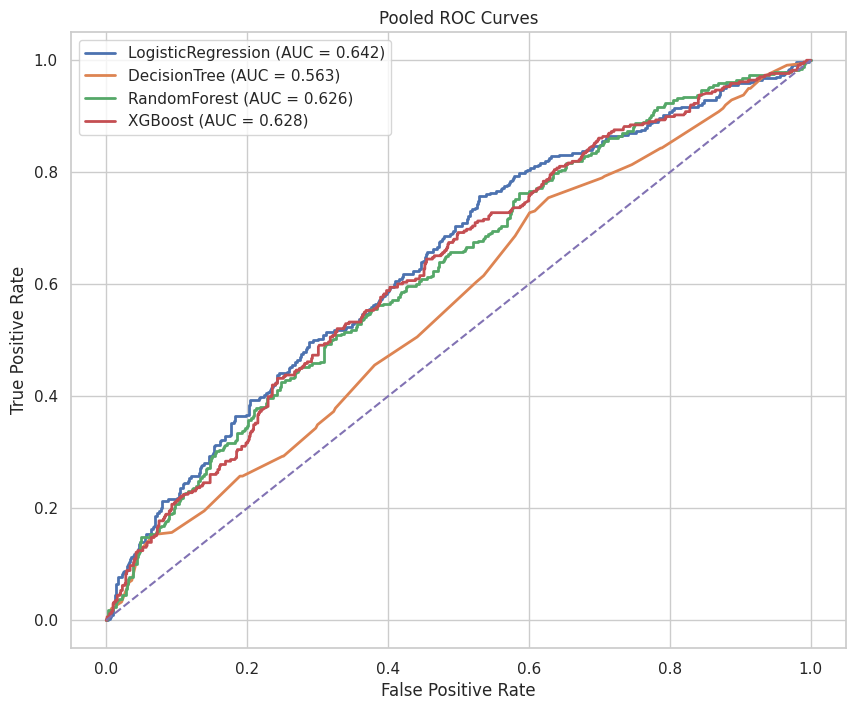

In [ ]:
# =====================================================
# POOLED ROC CURVES
# =====================================================

plt.figure(figsize=(10,8))

models_list = results_selected['model'].unique()

for model_name in models_list:

    model_df = results_selected[
        results_selected['model'] == model_name
    ]

    # ---------------------------------------------
    # POOL PREDICTIONS ACROSS FOLDS
    # ---------------------------------------------

    y_true = np.concatenate(
        model_df['y_true'].values
    )

    y_proba = np.concatenate(
        model_df['y_proba'].values
    )

    # ---------------------------------------------
    # ROC
    # ---------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_true,
        y_proba
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Pooled ROC Curves')
plt.legend()
plt.grid(True)

plt.show()

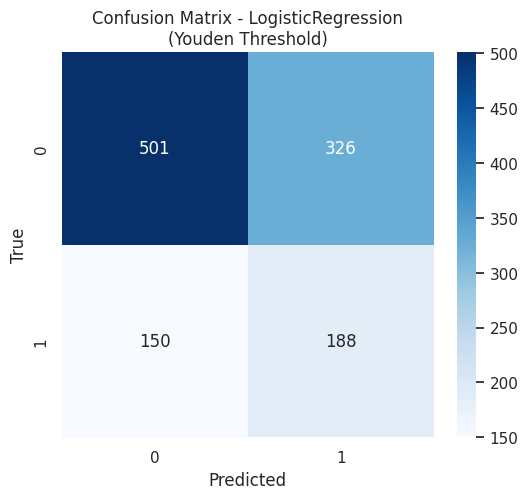

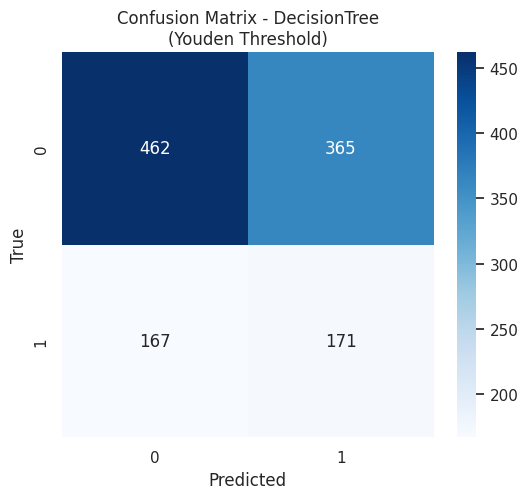

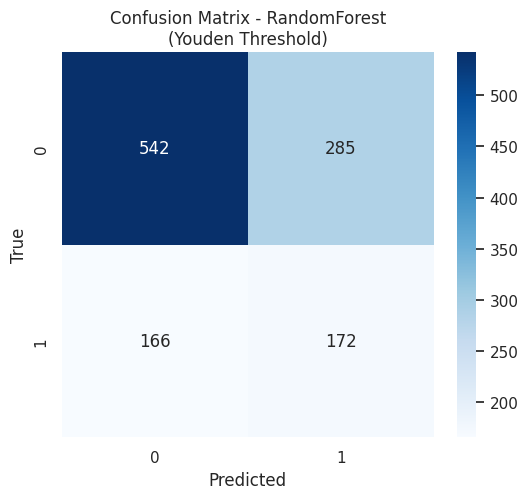

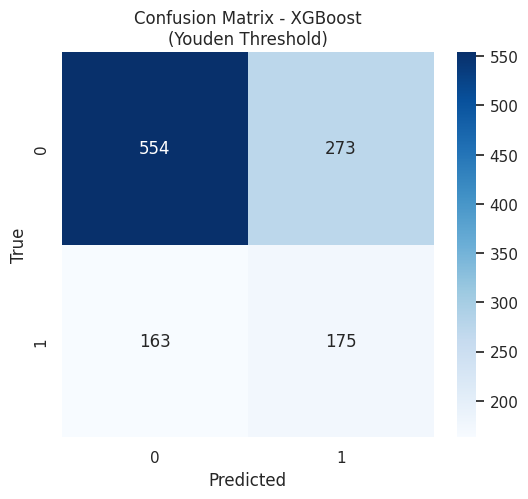

In [ ]:
# =====================================================
# CONFUSION MATRICES USING STORED YOUDEN PREDICTIONS
# =====================================================

for model_name in results_selected['model'].unique():

    model_df = results_selected[
        results_selected['model'] == model_name
    ]

    # ---------------------------------------------
    # POOL FOLD PREDICTIONS
    # ---------------------------------------------

    y_true = np.concatenate(
        model_df['y_true'].values
    )

    # These predictions already use the
    # Youden threshold computed inside CV
    y_pred = np.concatenate(
        model_df['y_pred'].values
    )

    # ---------------------------------------------
    # CONFUSION MATRIX
    # ---------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # Optional: mean threshold across folds
    if 'best_threshold' in model_df.columns:
        mean_threshold = model_df[
            'best_threshold'
        ].mean()

        title = (
            f'Confusion Matrix - {model_name}\n'
            f'(Youden Threshold mean = {mean_threshold:.3f})'
        )
    else:
        title = (
            f'Confusion Matrix - {model_name}\n'
            f'(Youden Threshold)'
        )

    # ---------------------------------------------
    # PLOT
    # ---------------------------------------------

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)

    plt.xlabel('Predicted')
    plt.ylabel('True')

    plt.show()


SHAP ANALYSIS: LogisticRegression


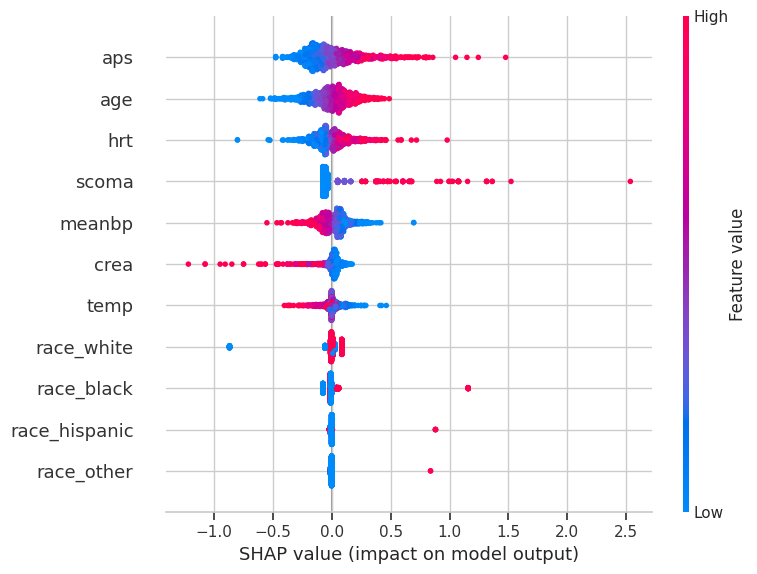


SHAP ANALYSIS: DecisionTree


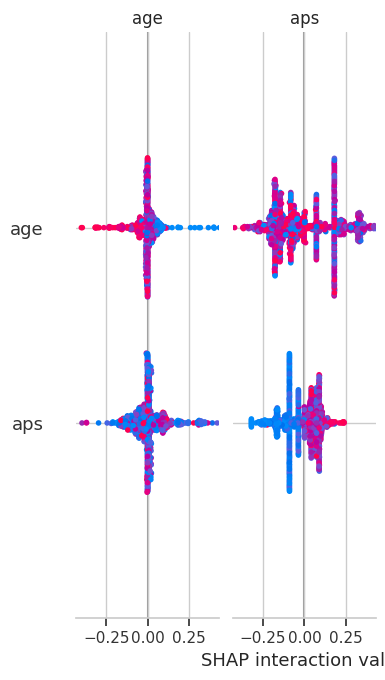


SHAP ANALYSIS: RandomForest


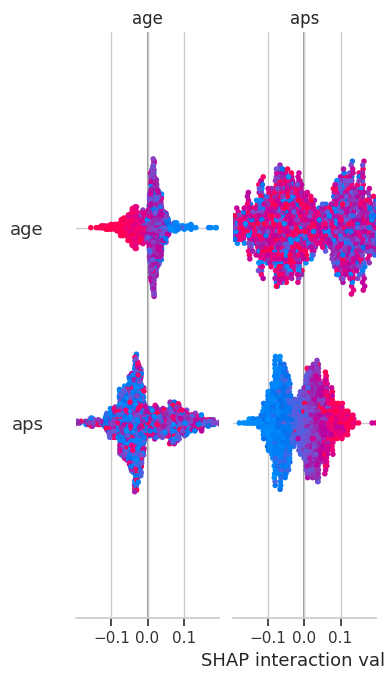


SHAP ANALYSIS: XGBoost


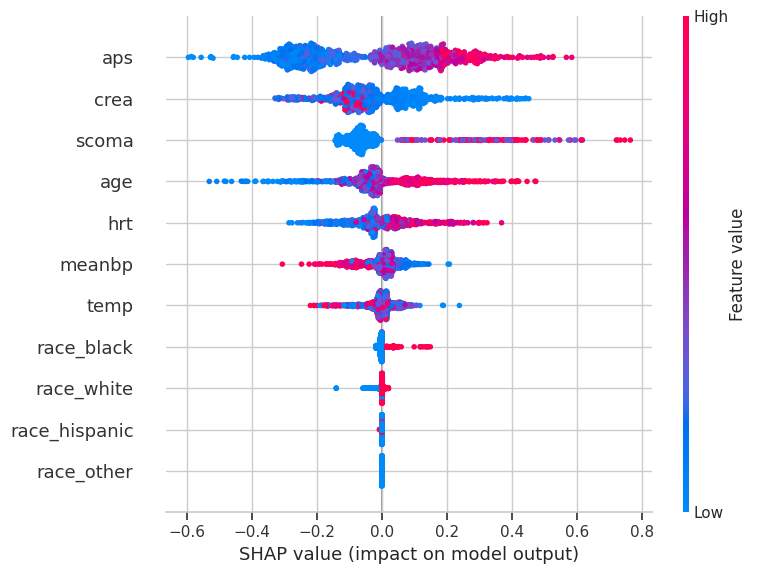

In [ ]:
# =====================================================
# SHAP VALUES FOR EACH MODEL
# =====================================================

import shap

for model_name in results_selected['model'].unique():

    print("\n====================================")
    print(f"SHAP ANALYSIS: {model_name}")
    print("====================================")

    model_df = results_selected[
        results_selected['model'] == model_name
    ]

    shap_values_all = []
    X_all = []

    # -------------------------------------------------
    # LOOP OVER OUTER FOLDS
    # -------------------------------------------------

    for _, row in model_df.iterrows():

        best_model = row['best_model']
        X_valid = row['X_valid']

        # Extract trained classifier
        clf = best_model.named_steps['model']

        # ---------------------------------------------
        # SHAP EXPLAINER
        # ---------------------------------------------

        if model_name in ['DecisionTree', 'RandomForest', 'XGBoost']:

            explainer = shap.TreeExplainer(clf)

            shap_values = explainer.shap_values(X_valid)

            # Binary classification
            if isinstance(shap_values, list):
                shap_values = shap_values[1]

        else:
            explainer = shap.Explainer(
                clf,
                X_valid
            )

            shap_values = explainer(
                X_valid
            ).values

        shap_values_all.append(shap_values)
        X_all.append(X_valid)

    # -------------------------------------------------
    # CONCATENATE ALL FOLDS
    # -------------------------------------------------

    shap_values_all = np.vstack(
        shap_values_all
    )

    X_all = pd.concat(
        X_all,
        axis=0
    )

    # -------------------------------------------------
    # SUMMARY PLOT
    # -------------------------------------------------

    shap.summary_plot(
        shap_values_all,
        X_all,
        show=True
    )

### Inference on Test Set

Fitting 5 folds for each of 8 candidates, totalling 40 fits

BEST PARAMETERS
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2'}

Best Youden Threshold: 0.4824

HELD-OUT TEST RESULTS
Accuracy : 0.5534
AUC      : 0.6039
F1 Score : 0.4524
Precision: 0.3519
Recall   : 0.6333


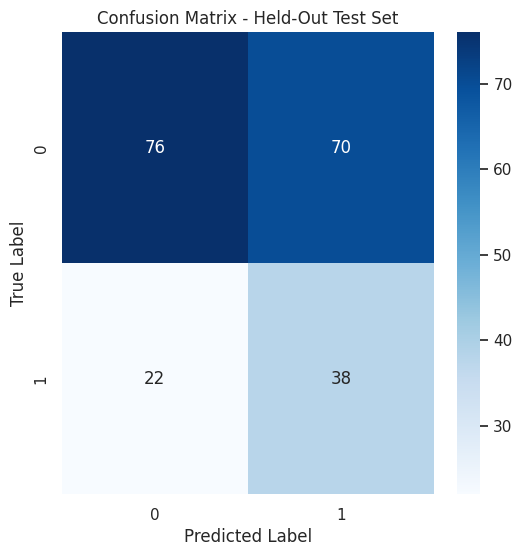

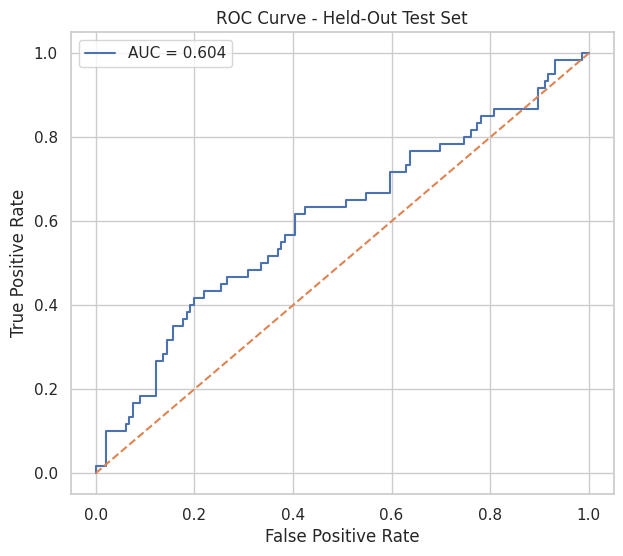

In [ ]:
# =========================================================
# LOAD TEST SET
# =========================================================

test_path = "support2_test.xlsx"

df_test = pd.read_excel(test_path)

target_col = "target"

# =========================================================
# SELECTED RAW FEATURES (RFE FEATURES)
# =========================================================

selected_features_raw = [
    'age',
    'aps',
    'scoma',
    'crea',
    'hrt',
    'meanbp',
    'temp',
    'race'
]

# =========================================================
# KEEP ONLY SELECTED FEATURES
# =========================================================

train_df = df_cv[
    selected_features_raw + [target_col]
].copy()

df_test = df_test[
    selected_features_raw + [target_col]
].copy()

# =========================================================
# IMPUTATION
# FIT ONLY ON TRAIN
# =========================================================

imputation_dict = custom_imputation_fit(
    train_df
)

train_df = custom_imputation_transform(
    train_df,
    imputation_dict
)

df_test = custom_imputation_transform(
    df_test,
    imputation_dict
)

# =========================================================
# PREPROCESSING
# FIT ONLY ON TRAIN
# =========================================================

preprocess_dict = preprocessing_fit(
    train_df
)

train_df = preprocessing_transform(
    train_df,
    preprocess_dict
)

df_test = preprocessing_transform(
    df_test,
    preprocess_dict
)

# =========================================================
# SPLIT FEATURES / TARGET
# =========================================================

X_train = train_df.drop(
    columns=[target_col]
).astype(float)

y_train = train_df[target_col]

X_test = df_test.drop(
    columns=[target_col]
).astype(float)

y_test = df_test[target_col]

# =========================================================
# ALIGN TEST FEATURES TO TRAIN FEATURES
# IMPORTANT AFTER PREPROCESSING
# =========================================================

train_features = X_train.columns

# add missing columns
for col in train_features:

    if col not in X_test.columns:

        X_test[col] = 0

# remove extra columns
X_test = X_test[train_features]

# enforce same order
X_test = X_test.reindex(
    columns=train_features
)

# =========================================================
# BALANCING
# =========================================================

under = RandomUnderSampler(
    sampling_strategy=0.67,
    random_state=42
)

smote = SMOTE(
    random_state=42
)

# =========================================================
# LOGISTIC REGRESSION PIPELINE
# =========================================================

pipeline = ImbPipeline([

    ('under', under),

    ('smote', smote),

    ('model',
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

# =========================================================
# PARAM GRID
# =========================================================

param_grid = {

    'model__C': [
        0.01,
        0.1,
        1,
        10
    ],

    'model__penalty': [
        'l2'
    ],

    'model__class_weight': [
        None,
        'balanced'
    ]
}

# =========================================================
# INNER CV FOR FINAL TUNING
# =========================================================

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# GRID SEARCH
# =========================================================

grid = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring='roc_auc',

    cv=inner_cv,

    n_jobs=-1,

    verbose=1
)

# =========================================================
# FINAL TRAINING ON ALL TRAINING DATA
# =========================================================

grid.fit(
    X_train,
    y_train
)

# =========================================================
# BEST MODEL
# =========================================================

final_model = grid.best_estimator_

print("\n================================================")
print("BEST PARAMETERS")
print("================================================")

print(grid.best_params_)

# =========================================================
# TRAIN PROBABILITIES
# =========================================================

y_train_proba = final_model.predict_proba(
    X_train
)[:,1]

# =========================================================
# YOUDEN THRESHOLD
# =========================================================

fpr, tpr, thresholds = roc_curve(
    y_train,
    y_train_proba
)

youden_j = tpr - fpr

best_threshold = thresholds[
    np.argmax(youden_j)
]

print(
    f"\nBest Youden Threshold: "
    f"{best_threshold:.4f}"
)

# =========================================================
# TEST INFERENCE
# =========================================================

y_test_proba = final_model.predict_proba(
    X_test
)[:,1]

y_test_pred = (
    y_test_proba >= best_threshold
).astype(int)

# =========================================================
# TEST METRICS
# =========================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

# =========================================================
# PRINT RESULTS
# =========================================================

print("\n================================================")
print("HELD-OUT TEST RESULTS")
print("================================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"AUC      : {test_auc:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(
    "Confusion Matrix - Held-Out Test Set"
)

plt.show()

# =========================================================
# ROC CURVE
# =========================================================

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"AUC = {test_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Held-Out Test Set"
)

plt.legend()

plt.show()

## c. PCA Model

In [ ]:
# =========================================================
# NESTED CV WITH PCA BASELINE COMPRESSION
# =========================================================

def nested_cv_evaluation_pca(
    df_cv,
    target_col='target',
    outer_splits=5,
    inner_splits=5,
    n_components=3
):

    # =====================================================
    # STORE RESULTS
    # =====================================================

    all_results = []

    # =====================================================
    # FEATURE GROUPS
    # =====================================================

    baseline_vars = [
        "age",
        "sex",
        "race",
        "edu",
        "income",
        "num.co",
        "diabetes",
        "metastatic"
    ]

    # =====================================================
    # SPLIT FEATURES / TARGET
    # =====================================================

    X = df_cv.drop(columns=[target_col])
    y = df_cv[target_col]

    # =====================================================
    # OUTER CV
    # =====================================================

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=42
    )

    # =====================================================
    # LOOP OVER MODELS
    # =====================================================

    for model_name, model_info in models.items():

        print("\n================================================")
        print(f"MODEL: {model_name}")
        print("================================================")

        outer_fold = 1

        fold_metrics = []

        # =================================================
        # OUTER LOOP
        # =================================================

        for train_idx, valid_idx in outer_cv.split(X, y):

            print(f"\nOuter Fold {outer_fold}")

            # -------------------------------------------------
            # SPLIT FOLDS
            # -------------------------------------------------

            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y.iloc[train_idx].copy()

            X_valid_fold = X.iloc[valid_idx].copy()
            y_valid_fold = y.iloc[valid_idx].copy()

            # -------------------------------------------------
            # REBUILD DATAFRAMES
            # -------------------------------------------------

            train_fold = X_train_fold.copy()
            train_fold[target_col] = y_train_fold.values

            valid_fold = X_valid_fold.copy()
            valid_fold[target_col] = y_valid_fold.values

            # =================================================
            # IMPUTATION
            # FIT ONLY ON TRAIN FOLD
            # =================================================

            imputation_dict = custom_imputation_fit(
                train_fold
            )

            train_fold = custom_imputation_transform(
                train_fold,
                imputation_dict
            )

            valid_fold = custom_imputation_transform(
                valid_fold,
                imputation_dict
            )

            # =================================================
            # PREPROCESSING
            # FIT ONLY ON TRAIN FOLD
            # =================================================

            preprocess_dict = preprocessing_fit(
                train_fold
            )

            train_fold = preprocessing_transform(
                train_fold,
                preprocess_dict
            )

            valid_fold = preprocessing_transform(
                valid_fold,
                preprocess_dict
            )

            # =================================================
            # SPLIT AGAIN
            # =================================================

            X_train_proc = train_fold.drop(columns=[target_col])
            y_train_proc = train_fold[target_col]

            X_valid_proc = valid_fold.drop(columns=[target_col])
            y_valid_proc = valid_fold[target_col]

            # =================================================
            # IDENTIFY PCA FEATURES
            # =================================================

            baseline_processed_cols = []

            for col in X_train_proc.columns:

                if (
                    col in [
                        'age',
                        'sex',
                        'edu',
                        'num.co',
                        'diabetes',
                        'metastatic'
                    ]
                    or col.startswith('race_')
                    or col.startswith('income_')
                ):

                    baseline_processed_cols.append(col)

            # =================================================
            # ALL OTHER FEATURES
            # =================================================

            other_features = [
                col for col in X_train_proc.columns
                if col not in baseline_processed_cols
            ]

            # =================================================
            # SPLIT BASELINE / OTHER
            # =================================================

            X_train_base = X_train_proc[
                baseline_processed_cols
            ].copy()

            X_valid_base = X_valid_proc[
                baseline_processed_cols
            ].copy()

            X_train_other = X_train_proc[
                other_features
            ].copy()

            X_valid_other = X_valid_proc[
                other_features
            ].copy()

            # =================================================
            # PCA
            # FIT ONLY ON TRAIN FOLD
            # =================================================

            pca = PCA(
                n_components=n_components,
                random_state=42
            )

            pca.fit(X_train_base)

            # =================================================
            # TRANSFORM
            # =================================================

            X_train_pca = pca.transform(
                X_train_base
            )

            X_valid_pca = pca.transform(
                X_valid_base
            )

            # =================================================
            # PCA DATAFRAMES
            # =================================================

            pca_cols = [
                f'baseline_pc{i+1}'
                for i in range(n_components)
            ]

            X_train_pca_df = pd.DataFrame(
                X_train_pca,
                columns=pca_cols,
                index=X_train_proc.index
            )

            X_valid_pca_df = pd.DataFrame(
                X_valid_pca,
                columns=pca_cols,
                index=X_valid_proc.index
            )

            # =================================================
            # FINAL DATASETS
            # =================================================

            X_train_final = pd.concat(
                [
                    X_train_other,
                    X_train_pca_df
                ],
                axis=1
            )

            X_valid_final = pd.concat(
                [
                    X_valid_other,
                    X_valid_pca_df
                ],
                axis=1
            )

            # =================================================
            # FLOAT CONVERSION
            # =================================================

            X_train_final = X_train_final.astype(float)
            X_valid_final = X_valid_final.astype(float)

            # =================================================
            # BALANCING
            # =================================================

            counter = Counter(y_train_proc)

            print("\nOriginal distribution:")
            print(counter)

            # -------------------------------------------------
            # UNDERSAMPLING
            # -------------------------------------------------

            under = RandomUnderSampler(
                sampling_strategy=0.67,
                random_state=42
            )

            # -------------------------------------------------
            # SMOTE
            # -------------------------------------------------

            smote = SMOTE(
                random_state=42
            )

            # =================================================
            # PIPELINE
            # =================================================

            pipeline = ImbPipeline([
                ('under', under),
                ('smote', smote),
                ('model', model_info['model'])
            ])

            # =================================================
            # PARAM GRID
            # =================================================

            param_grid = {
                f'model__{k}': v
                for k, v in model_info['params'].items()
            }

            # =================================================
            # INNER CV
            # =================================================

            inner_cv = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=42
            )

            # =================================================
            # GRID SEARCH
            # =================================================

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=-1,
                verbose=0,
                error_score='raise'
            )

            # =================================================
            # FIT GRID
            # =================================================

            grid.fit(
                X_train_final,
                y_train_proc
            )

            best_model = grid.best_estimator_

            # =================================================
            # PREDICT PROBABILITIES
            # =================================================

            y_train_proba = best_model.predict_proba(
                X_train_final
            )[:,1]

            y_valid_proba = best_model.predict_proba(
                X_valid_final
            )[:,1]

            # =================================================
            # YOUDEN THRESHOLD
            # =================================================

            fpr, tpr, thresholds = roc_curve(
                y_train_proc,
                y_train_proba
            )

            youden_j = tpr - fpr

            best_threshold = thresholds[
                np.argmax(youden_j)
            ]

            print(
                f"Soglia ottimale Fold "
                f"{outer_fold}: "
                f"{best_threshold:.4f}"
            )

            # =================================================
            # FINAL PREDICTIONS
            # =================================================

            y_train_pred = (
                y_train_proba >= best_threshold
            ).astype(int)

            y_valid_pred = (
                y_valid_proba >= best_threshold
            ).astype(int)

            # =================================================
            # METRICS
            # =================================================

            metrics_dict = {

                'model': model_name,

                'outer_fold': outer_fold,

                # =============================================
                # TRAIN METRICS
                # =============================================

                'train_accuracy':
                    accuracy_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_auc':
                    roc_auc_score(
                        y_train_proc,
                        y_train_proba
                    ),

                'train_f1':
                    f1_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_precision':
                    precision_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_recall':
                    recall_score(
                        y_train_proc,
                        y_train_pred
                    ),

                # =============================================
                # VALID METRICS
                # =============================================

                'valid_accuracy':
                    accuracy_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_auc':
                    roc_auc_score(
                        y_valid_proc,
                        y_valid_proba
                    ),

                'valid_f1':
                    f1_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_precision':
                    precision_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_recall':
                    recall_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                # =============================================
                # STORE PREDICTIONS
                # =============================================

                'y_true':
                    list(y_valid_proc),

                'y_pred':
                    list(y_valid_pred),

                'y_proba':
                    list(y_valid_proba),

                # =============================================
                # STORE OBJECTS
                # =============================================

                'best_model':
                    best_model,

                'pca_model':
                    pca,

                'X_valid':
                    X_valid_final,

                'feature_names':
                    X_valid_final.columns.tolist(),

                # =============================================
                # PCA INFO
                # =============================================

                'explained_variance':
                    pca.explained_variance_ratio_,

                # =============================================
                # BEST PARAMS
                # =============================================

                'best_params':
                    grid.best_params_
            }

            # =================================================
            # SAVE FOLD RESULTS
            # =================================================

            fold_metrics.append(
                metrics_dict
            )

            print(
                f"Validation AUC: "
                f"{metrics_dict['valid_auc']:.4f}"
            )

            outer_fold += 1

        # =================================================
        # SAVE MODEL RESULTS
        # =================================================

        model_results = pd.DataFrame(
            fold_metrics
        )

        all_results.append(
            model_results
        )

    # =====================================================
    # CONCATENATE RESULTS
    # =====================================================

    final_results = pd.concat(
        all_results,
        axis=0
    )

    return final_results

In [ ]:
results_pca = nested_cv_evaluation_pca(
    df_cv=df_cv,
    target_col='target',
    outer_splits=5,
    inner_splits=5,
    n_components=3
)


MODEL: LogisticRegression

Outer Fold 1

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 1: 0.5051
Validation AUC: 0.6149

Outer Fold 2

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 2: 0.4578
Validation AUC: 0.6360

Outer Fold 3

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 3: 0.4942
Validation AUC: 0.6271

Outer Fold 4

Original distribution:
Counter({0: 661, 1: 271})
Soglia ottimale Fold 4: 0.4570
Validation AUC: 0.5923

Outer Fold 5

Original distribution:
Counter({0: 661, 1: 271})
Soglia ottimale Fold 5: 0.4861
Validation AUC: 0.6590

MODEL: DecisionTree

Outer Fold 1

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 1: 0.5104
Validation AUC: 0.5502

Outer Fold 2

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 2: 0.5471
Validation AUC: 0.6503

Outer Fold 3

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 3: 0.5455
Validation AUC: 0.6221

Outer F

In [ ]:
# =========================================================
# METRICS TO SUMMARIZE
# =========================================================

metrics_cols = [
    'train_accuracy',
    'train_auc',
    'train_f1',
    'train_precision',
    'train_recall',
    'valid_accuracy',
    'valid_auc',
    'valid_f1',
    'valid_precision',
    'valid_recall'
]

# =========================================================
# COMPUTE MEAN
# =========================================================

mean_df = results_pca.groupby('model')[metrics_cols].mean()

# =========================================================
# COMPUTE STANDARD DEVIATION
# =========================================================

std_df = results_pca.groupby('model')[metrics_cols].std()

# =========================================================
# CREATE COMBINED TABLE
# =========================================================

summary_table = mean_df.copy()

for col in metrics_cols:

    summary_table[col] = (
        mean_df[col].round(3).astype(str)
        + " ± "
        + std_df[col].round(3).astype(str)
    )

# =========================================================
# PRINT
# =========================================================

print(summary_table)

                   train_accuracy      train_auc       train_f1  \
model                                                             
DecisionTree        0.648 ± 0.104   0.73 ± 0.108  0.553 ± 0.101   
LogisticRegression  0.603 ± 0.024  0.657 ± 0.009   0.49 ± 0.017   
RandomForest        0.822 ± 0.088  0.897 ± 0.059  0.741 ± 0.121   
XGBoost              0.746 ± 0.08   0.844 ± 0.06   0.66 ± 0.086   

                   train_precision   train_recall valid_accuracy  \
model                                                              
DecisionTree         0.449 ± 0.114   0.73 ± 0.063  0.557 ± 0.031   
LogisticRegression    0.392 ± 0.01  0.659 ± 0.079  0.583 ± 0.041   
RandomForest         0.664 ± 0.156  0.848 ± 0.074  0.614 ± 0.043   
XGBoost              0.556 ± 0.119   0.829 ± 0.05  0.599 ± 0.054   

                        valid_auc       valid_f1 valid_precision  \
model                                                              
DecisionTree         0.614 ± 0.04  0.438 ± 0.028    

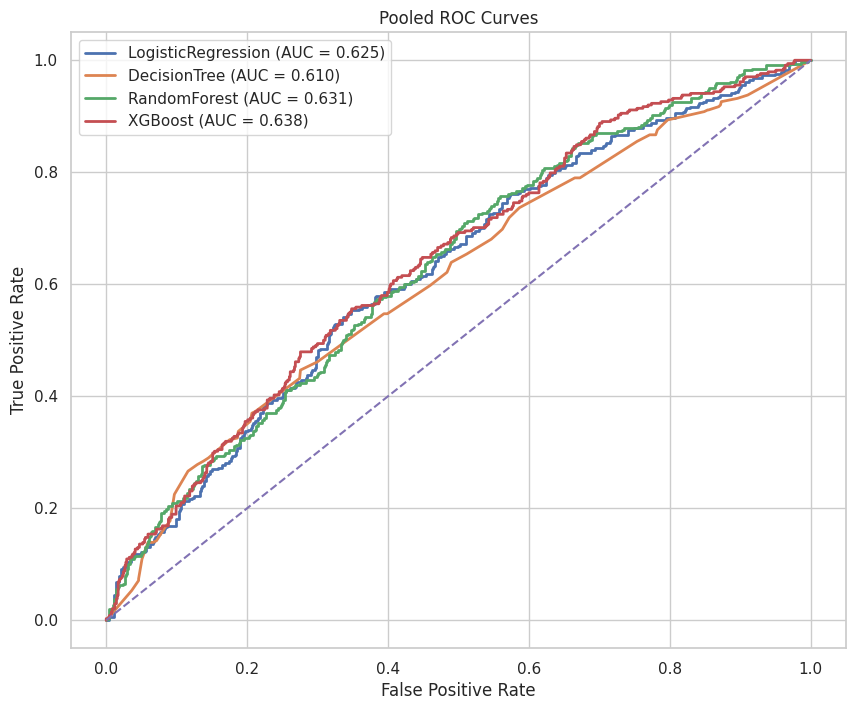

In [ ]:
# =====================================================
# POOLED ROC CURVES
# =====================================================

plt.figure(figsize=(10,8))

models_list = results_pca['model'].unique()

for model_name in models_list:

    model_df = results_pca[
        results_pca['model'] == model_name
    ]

    # ---------------------------------------------
    # POOL PREDICTIONS ACROSS FOLDS
    # ---------------------------------------------

    y_true = np.concatenate(
        model_df['y_true'].values
    )

    y_proba = np.concatenate(
        model_df['y_proba'].values
    )

    # ---------------------------------------------
    # ROC
    # ---------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_true,
        y_proba
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Pooled ROC Curves')
plt.legend()
plt.grid(True)

plt.show()

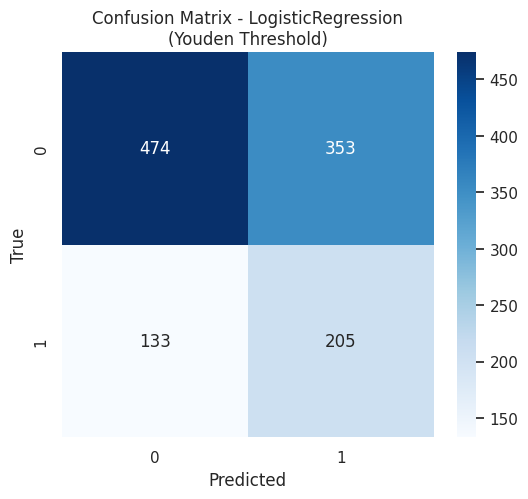

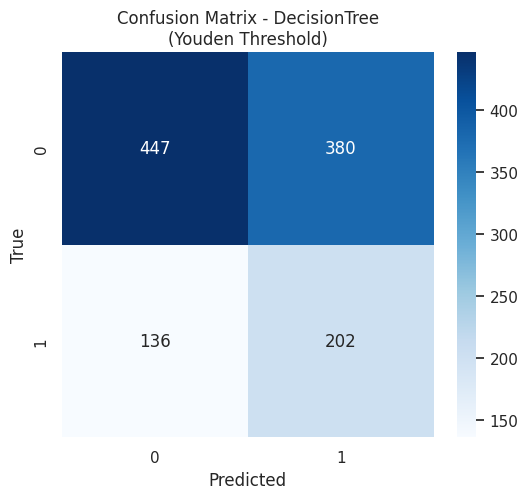

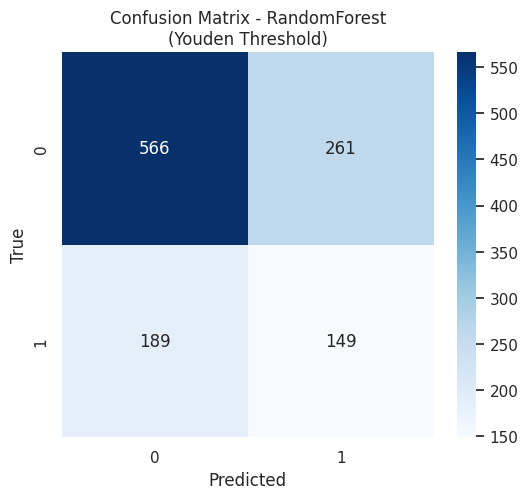

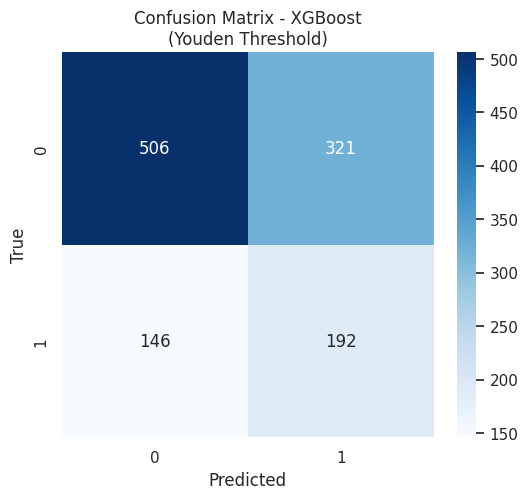

In [ ]:
# =====================================================
# CONFUSION MATRICES USING STORED YOUDEN PREDICTIONS
# =====================================================

for model_name in results_pca['model'].unique():

    model_df = results_pca[
        results_pca['model'] == model_name
    ]

    # ---------------------------------------------
    # POOL FOLD PREDICTIONS
    # ---------------------------------------------

    y_true = np.concatenate(
        model_df['y_true'].values
    )

    # These predictions already use the
    # Youden threshold computed inside CV
    y_pred = np.concatenate(
        model_df['y_pred'].values
    )

    # ---------------------------------------------
    # CONFUSION MATRIX
    # ---------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # Optional: mean threshold across folds
    if 'best_threshold' in model_df.columns:
        mean_threshold = model_df[
            'best_threshold'
        ].mean()

        title = (
            f'Confusion Matrix - {model_name}\n'
            f'(Youden Threshold mean = {mean_threshold:.3f})'
        )
    else:
        title = (
            f'Confusion Matrix - {model_name}\n'
            f'(Youden Threshold)'
        )

    # ---------------------------------------------
    # PLOT
    # ---------------------------------------------

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)

    plt.xlabel('Predicted')
    plt.ylabel('True')

    plt.show()

### Inference on Test Set

Fitting 5 folds for each of 8 candidates, totalling 40 fits

BEST PARAMETERS
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2'}

Best Youden Threshold: 0.4937

HELD-OUT TEST RESULTS
Accuracy : 0.6117
AUC      : 0.6084
F1 Score : 0.4937
Precision: 0.3980
Recall   : 0.6500


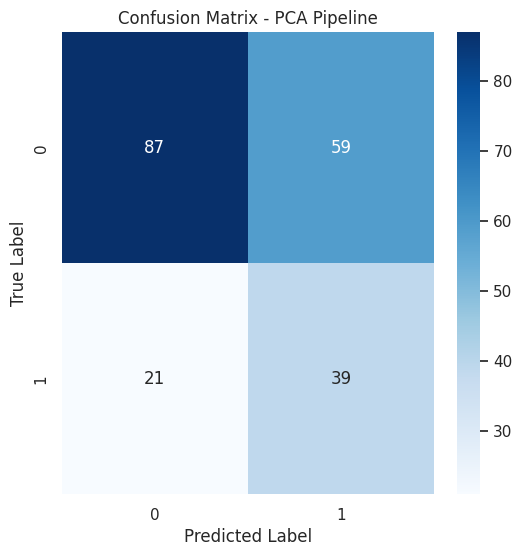

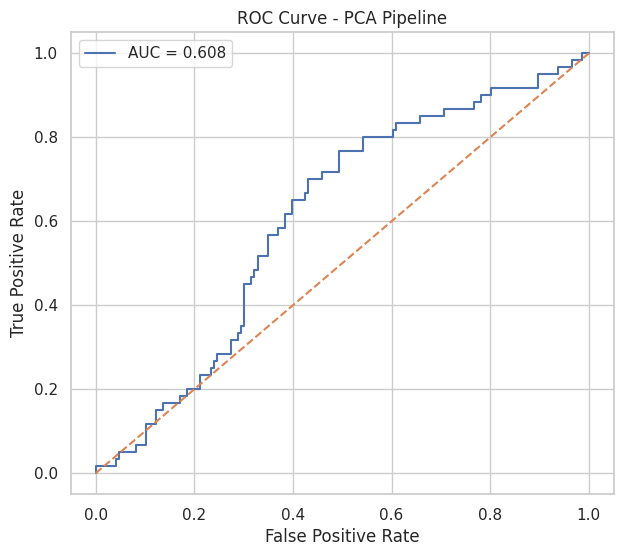


PCA EXPLAINED VARIANCE
PC1: 0.3299
PC2: 0.1938
PC3: 0.1623

Total explained variance: 0.6860


In [ ]:
# =========================================================
# LOAD TEST SET
# =========================================================

test_path = "support2_test.xlsx"

df_test = pd.read_excel(test_path)

target_col = "target"

# =========================================================
# TRAIN = FULL CV DATASET
# =========================================================

train_df = df_cv.copy()

# =========================================================
# IMPUTATION
# FIT ONLY ON TRAIN
# =========================================================

imputation_dict = custom_imputation_fit(
    train_df
)

train_df = custom_imputation_transform(
    train_df,
    imputation_dict
)

df_test = custom_imputation_transform(
    df_test,
    imputation_dict
)

# =========================================================
# PREPROCESSING
# FIT ONLY ON TRAIN
# =========================================================

preprocess_dict = preprocessing_fit(
    train_df
)

train_df = preprocessing_transform(
    train_df,
    preprocess_dict
)

df_test = preprocessing_transform(
    df_test,
    preprocess_dict
)

# =========================================================
# SPLIT FEATURES / TARGET
# =========================================================

X_train_proc = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test_proc = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

# =========================================================
# IDENTIFY PCA FEATURES
# SAME LOGIC USED IN CV
# =========================================================

baseline_processed_cols = []

for col in X_train_proc.columns:

    if (
        col in [
            'age',
            'sex',
            'edu',
            'num.co',
            'diabetes',
            'metastatic'
        ]
        or col.startswith('race_')
        or col.startswith('income_')
    ):

        baseline_processed_cols.append(col)

# =========================================================
# OTHER FEATURES
# =========================================================

other_features = [
    col for col in X_train_proc.columns
    if col not in baseline_processed_cols
]

# =========================================================
# ALIGN TEST FEATURES
# =========================================================

for col in X_train_proc.columns:

    if col not in X_test_proc.columns:
        X_test_proc[col] = 0

X_test_proc = X_test_proc[
    X_train_proc.columns
]

# =========================================================
# SPLIT BASELINE / OTHER
# =========================================================

X_train_base = X_train_proc[
    baseline_processed_cols
].copy()

X_test_base = X_test_proc[
    baseline_processed_cols
].copy()

X_train_other = X_train_proc[
    other_features
].copy()

X_test_other = X_test_proc[
    other_features
].copy()

# =========================================================
# PCA
# FIT ONLY ON TRAIN
# =========================================================

n_components = 3

pca = PCA(
    n_components=n_components,
    random_state=42
)

pca.fit(X_train_base)

# =========================================================
# TRANSFORM TRAIN + TEST
# =========================================================

X_train_pca = pca.transform(
    X_train_base
)

X_test_pca = pca.transform(
    X_test_base
)

# =========================================================
# PCA DATAFRAMES
# =========================================================

pca_cols = [
    f'baseline_pc{i+1}'
    for i in range(n_components)
]

X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pca_cols,
    index=X_train_proc.index
)

X_test_pca_df = pd.DataFrame(
    X_test_pca,
    columns=pca_cols,
    index=X_test_proc.index
)

# =========================================================
# FINAL DATASETS
# =========================================================

X_train_final = pd.concat(
    [
        X_train_other,
        X_train_pca_df
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_other,
        X_test_pca_df
    ],
    axis=1
)

# =========================================================
# FLOAT CONVERSION
# =========================================================

X_train_final = X_train_final.astype(float)
X_test_final = X_test_final.astype(float)

# =========================================================
# BALANCING
# =========================================================

under = RandomUnderSampler(
    sampling_strategy=0.67,
    random_state=42
)

smote = SMOTE(
    random_state=42
)

# =========================================================
# LOGISTIC REGRESSION PIPELINE
# =========================================================

pipeline = ImbPipeline([

    ('under', under),

    ('smote', smote),

    ('model',
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

# =========================================================
# PARAM GRID
# =========================================================

param_grid = {

    'model__C': [0.01, 0.1, 1, 10],

    'model__penalty': ['l2'],

    'model__class_weight': [
        None,
        'balanced'
    ]
}

# =========================================================
# INNER CV
# =========================================================

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# GRID SEARCH
# =========================================================

grid = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring='roc_auc',

    cv=inner_cv,

    n_jobs=-1,

    verbose=1
)

# =========================================================
# TRAIN FINAL MODEL
# =========================================================

grid.fit(
    X_train_final,
    y_train
)

# =========================================================
# BEST MODEL
# =========================================================

final_model = grid.best_estimator_

print("\n================================================")
print("BEST PARAMETERS")
print("================================================")

print(grid.best_params_)

# =========================================================
# TRAIN PROBABILITIES
# =========================================================

y_train_proba = final_model.predict_proba(
    X_train_final
)[:,1]

# =========================================================
# YOUDEN THRESHOLD
# =========================================================

fpr, tpr, thresholds = roc_curve(
    y_train,
    y_train_proba
)

youden_j = tpr - fpr

best_threshold = thresholds[
    np.argmax(youden_j)
]

print(f"\nBest Youden Threshold: {best_threshold:.4f}")

# =========================================================
# TEST INFERENCE
# =========================================================

y_test_proba = final_model.predict_proba(
    X_test_final
)[:,1]

y_test_pred = (
    y_test_proba >= best_threshold
).astype(int)

# =========================================================
# TEST METRICS
# =========================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

# =========================================================
# PRINT RESULTS
# =========================================================

print("\n================================================")
print("HELD-OUT TEST RESULTS")
print("================================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"AUC      : {test_auc:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "Confusion Matrix - PCA Pipeline"
)

plt.show()

# =========================================================
# ROC CURVE
# =========================================================

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"AUC = {test_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - PCA Pipeline"
)

plt.legend()

plt.show()

# =========================================================
# EXPLAINED VARIANCE
# =========================================================

print("\n================================================")
print("PCA EXPLAINED VARIANCE")
print("================================================")

for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

print(
    f"\nTotal explained variance: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)

## d. Autoencoder Model

In [ ]:
# =========================================================
# SIMPLE AUTOENCODER
# =========================================================

class Autoencoder(nn.Module):

    def __init__(self, input_dim, embedding_dim=3):

        super(Autoencoder, self).__init__()

        # -------------------------------------------------
        # ENCODER
        # -------------------------------------------------

        self.encoder = nn.Sequential(

            nn.Linear(input_dim, 8),
            nn.ReLU(),

            nn.Dropout(0.1),

            nn.Linear(8, embedding_dim)

        )

        # -------------------------------------------------
        # DECODER
        # -------------------------------------------------

        self.decoder = nn.Sequential(

            nn.Linear(embedding_dim, 8),
            nn.ReLU(),

            nn.Linear(8, input_dim)

        )

    # =====================================================
    # FORWARD
    # =====================================================

    def forward(self, x):

        embedding = self.encoder(x)

        reconstruction = self.decoder(embedding)

        return reconstruction


In [ ]:
# =========================================================
# NESTED CV WITH AUTOENCODER EMBEDDINGS
# =========================================================

def nested_cv_evaluation_autoencoder(
    df_cv,
    target_col='target',
    outer_splits=5,
    inner_splits=5,
    embedding_dim=3,
    ae_epochs=100,
    ae_batch_size=32,
    ae_lr=1e-3
):

    # =====================================================
    # STORE RESULTS
    # =====================================================

    all_results = []

    # =====================================================
    # BASELINE VARIABLES
    # =====================================================

    baseline_vars = [
        "age",
        "sex",
        "race",
        "edu",
        "income",
        "num.co",
        "diabetes",
        "metastatic"
    ]

    # =====================================================
    # SPLIT FEATURES / TARGET
    # =====================================================

    X = df_cv.drop(columns=[target_col])

    y = df_cv[target_col]

    # =====================================================
    # OUTER CV
    # =====================================================

    outer_cv = StratifiedKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=42
    )

    # =====================================================
    # LOOP OVER MODELS
    # =====================================================

    for model_name, model_info in models.items():

        print("\n================================================")
        print(f"MODEL: {model_name}")
        print("================================================")

        outer_fold = 1

        fold_metrics = []

        # =================================================
        # OUTER LOOP
        # =================================================

        for train_idx, valid_idx in outer_cv.split(X, y):

            print(f"\nOuter Fold {outer_fold}")

            # -------------------------------------------------
            # SPLIT FOLDS
            # -------------------------------------------------

            X_train_fold = X.iloc[train_idx].copy()
            y_train_fold = y.iloc[train_idx].copy()

            X_valid_fold = X.iloc[valid_idx].copy()
            y_valid_fold = y.iloc[valid_idx].copy()

            # -------------------------------------------------
            # REBUILD DATAFRAMES
            # -------------------------------------------------

            train_fold = X_train_fold.copy()
            train_fold[target_col] = y_train_fold.values

            valid_fold = X_valid_fold.copy()
            valid_fold[target_col] = y_valid_fold.values

            # =================================================
            # IMPUTATION
            # =================================================

            imputation_dict = custom_imputation_fit(
                train_fold
            )

            train_fold = custom_imputation_transform(
                train_fold,
                imputation_dict
            )

            valid_fold = custom_imputation_transform(
                valid_fold,
                imputation_dict
            )

            # =================================================
            # PREPROCESSING
            # =================================================

            preprocess_dict = preprocessing_fit(
                train_fold
            )

            train_fold = preprocessing_transform(
                train_fold,
                preprocess_dict
            )

            valid_fold = preprocessing_transform(
                valid_fold,
                preprocess_dict
            )

            # =================================================
            # SPLIT AGAIN
            # =================================================

            X_train_proc = train_fold.drop(columns=[target_col])

            y_train_proc = train_fold[target_col]

            X_valid_proc = valid_fold.drop(columns=[target_col])

            y_valid_proc = valid_fold[target_col]

            # =================================================
            # IDENTIFY BASELINE PROCESSED COLUMNS
            # =================================================

            baseline_processed_cols = []

            for col in X_train_proc.columns:

                if (
                    col in [
                        'age',
                        'sex',
                        'edu',
                        'num.co',
                        'diabetes',
                        'metastatic'
                    ]
                    or col.startswith('race_')
                    or col.startswith('income_')
                ):

                    baseline_processed_cols.append(col)

            # =================================================
            # OTHER FEATURES
            # =================================================

            other_features = [

                col for col in X_train_proc.columns

                if col not in baseline_processed_cols
            ]

            # =================================================
            # SPLIT BASELINE / OTHER
            # =================================================

            X_train_base = X_train_proc[
                baseline_processed_cols
            ].copy()

            X_valid_base = X_valid_proc[
                baseline_processed_cols
            ].copy()

            X_train_other = X_train_proc[
                other_features
            ].copy()

            X_valid_other = X_valid_proc[
                other_features
            ].copy()

            # =================================================
            # CONVERT TO FLOAT
            # =================================================

            X_train_base = X_train_base.astype(float)

            X_valid_base = X_valid_base.astype(float)

            # =================================================
            # TORCH TENSORS
            # =================================================

            X_train_tensor = torch.tensor(
                X_train_base.values,
                dtype=torch.float32
            )

            X_valid_tensor = torch.tensor(
                X_valid_base.values,
                dtype=torch.float32
            )

            # =================================================
            # DATA LOADER
            # =================================================

            train_dataset = TensorDataset(
                X_train_tensor
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=ae_batch_size,
                shuffle=True
            )

            # =================================================
            # AUTOENCODER
            # =================================================

            input_dim = X_train_base.shape[1]

            autoencoder = Autoencoder(
                input_dim=input_dim,
                embedding_dim=embedding_dim
            )

            # =================================================
            # LOSS + OPTIMIZER
            # =================================================

            criterion = nn.MSELoss()

            optimizer = torch.optim.Adam(
                autoencoder.parameters(),
                lr=ae_lr
            )

            # =================================================
            # TRAIN AUTOENCODER
            # =================================================

            autoencoder.train()

            for epoch in range(ae_epochs):

                epoch_loss = 0

                for batch in train_loader:

                    batch_x = batch[0]

                    optimizer.zero_grad()

                    reconstruction = autoencoder(batch_x)

                    loss = criterion(
                        reconstruction,
                        batch_x
                    )

                    loss.backward()

                    optimizer.step()

                    epoch_loss += loss.item()

                if (epoch + 1) % 20 == 0:

                    print(
                        f"AE Epoch {epoch+1}/{ae_epochs} "
                        f"- Loss: "
                        f"{epoch_loss / len(train_loader):.6f}"
                    )

            # =================================================
            # EXTRACT EMBEDDINGS
            # =================================================

            autoencoder.eval()

            with torch.no_grad():

                train_embeddings = autoencoder.encoder(
                    X_train_tensor
                ).numpy()

                valid_embeddings = autoencoder.encoder(
                    X_valid_tensor
                ).numpy()

            # =================================================
            # EMBEDDING DATAFRAMES
            # =================================================

            embedding_cols = [

                f'baseline_emb{i+1}'

                for i in range(embedding_dim)
            ]

            X_train_emb_df = pd.DataFrame(
                train_embeddings,
                columns=embedding_cols,
                index=X_train_proc.index
            )

            X_valid_emb_df = pd.DataFrame(
                valid_embeddings,
                columns=embedding_cols,
                index=X_valid_proc.index
            )

            # =================================================
            # FINAL DATASETS
            # =================================================

            X_train_final = pd.concat(
                [
                    X_train_other,
                    X_train_emb_df
                ],
                axis=1
            )

            X_valid_final = pd.concat(
                [
                    X_valid_other,
                    X_valid_emb_df
                ],
                axis=1
            )

            # =================================================
            # FINAL FLOAT CONVERSION
            # =================================================

            X_train_final = X_train_final.astype(float)

            X_valid_final = X_valid_final.astype(float)

            # =================================================
            # CHECK NaNs
            # =================================================

            if X_train_final.isna().sum().sum() > 0:

                print("\nWARNING: NaNs in training data")

            if X_valid_final.isna().sum().sum() > 0:

                print("\nWARNING: NaNs in validation data")

            # =================================================
            # BALANCING
            # =================================================

            counter = Counter(y_train_proc)

            print("\nOriginal distribution:")
            print(counter)

            under = RandomUnderSampler(
                sampling_strategy=0.67,
                random_state=42
            )

            smote = SMOTE(
                random_state=42
            )

            # =================================================
            # PIPELINE
            # =================================================

            pipeline = ImbPipeline([

                ('under', under),

                ('smote', smote),

                ('model', model_info['model'])

            ])

            # =================================================
            # PARAM GRID
            # =================================================

            param_grid = {

                f'model__{k}': v

                for k, v in model_info['params'].items()
            }

            # =================================================
            # INNER CV
            # =================================================

            inner_cv = StratifiedKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=42
            )

            # =================================================
            # GRID SEARCH
            # =================================================

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='roc_auc',
                cv=inner_cv,
                n_jobs=-1,
                verbose=0,
                error_score='raise'
            )

            # =================================================
            # FIT GRID
            # =================================================

            grid.fit(
                X_train_final,
                y_train_proc
            )

            best_model = grid.best_estimator_

            # =================================================
            # PROBABILITIES
            # =================================================

            y_train_proba = best_model.predict_proba(
                X_train_final
            )[:,1]

            y_valid_proba = best_model.predict_proba(
                X_valid_final
            )[:,1]

            # =================================================
            # YOUDEN THRESHOLD
            # =================================================

            fpr, tpr, thresholds = roc_curve(
                y_train_proc,
                y_train_proba
            )

            youden_j = tpr - fpr

            best_threshold = thresholds[
                np.argmax(youden_j)
            ]

            print(
                f"Soglia ottimale Fold "
                f"{outer_fold}: "
                f"{best_threshold:.4f}"
            )

            # =================================================
            # FINAL PREDICTIONS
            # =================================================

            y_train_pred = (
                y_train_proba >= best_threshold
            ).astype(int)

            y_valid_pred = (
                y_valid_proba >= best_threshold
            ).astype(int)

            # =================================================
            # METRICS
            # =================================================

            metrics_dict = {

                'model': model_name,

                'outer_fold': outer_fold,

                # -------------------------------------------------
                # TRAIN
                # -------------------------------------------------

                'train_accuracy':
                    accuracy_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_auc':
                    roc_auc_score(
                        y_train_proc,
                        y_train_proba
                    ),

                'train_f1':
                    f1_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_precision':
                    precision_score(
                        y_train_proc,
                        y_train_pred
                    ),

                'train_recall':
                    recall_score(
                        y_train_proc,
                        y_train_pred
                    ),

                # -------------------------------------------------
                # VALID
                # -------------------------------------------------

                'valid_accuracy':
                    accuracy_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_auc':
                    roc_auc_score(
                        y_valid_proc,
                        y_valid_proba
                    ),

                'valid_f1':
                    f1_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_precision':
                    precision_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                'valid_recall':
                    recall_score(
                        y_valid_proc,
                        y_valid_pred
                    ),

                # -------------------------------------------------
                # STORE PREDICTIONS
                # -------------------------------------------------

                'y_true':
                    list(y_valid_proc),

                'y_pred':
                    list(y_valid_pred),

                'y_proba':
                    list(y_valid_proba),

                # -------------------------------------------------
                # STORE
                # -------------------------------------------------

                'best_model':
                    best_model,

                'autoencoder':
                    autoencoder,

                'embedding_dim':
                    embedding_dim,

                'best_params':
                    grid.best_params_

            }

            # =================================================
            # SAVE RESULTS
            # =================================================

            fold_metrics.append(
                metrics_dict
            )

            print(
                f"Validation AUC: "
                f"{metrics_dict['valid_auc']:.4f}"
            )

            outer_fold += 1

        # =================================================
        # SAVE MODEL RESULTS
        # =================================================

        model_results = pd.DataFrame(
            fold_metrics
        )

        all_results.append(
            model_results
        )

    # =====================================================
    # CONCATENATE RESULTS
    # =====================================================

    final_results = pd.concat(
        all_results,
        axis=0
    )

    return final_results

In [ ]:
results_ae = nested_cv_evaluation_autoencoder(
    df_cv=df_cv,
    target_col='target',
    outer_splits=5,
    inner_splits=5,

    # =========================================
    # AUTOENCODER SETTINGS
    # =========================================

    embedding_dim=3,     # bottleneck size

    ae_epochs=100,       # can try 50 / 100 / 200

    ae_batch_size=32,

    ae_lr=1e-3
)


MODEL: LogisticRegression

Outer Fold 1
AE Epoch 20/100 - Loss: 0.175421
AE Epoch 40/100 - Loss: 0.143274
AE Epoch 60/100 - Loss: 0.125294
AE Epoch 80/100 - Loss: 0.119851
AE Epoch 100/100 - Loss: 0.121451

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 1: 0.5248
Validation AUC: 0.6097

Outer Fold 2
AE Epoch 20/100 - Loss: 0.139850
AE Epoch 40/100 - Loss: 0.123524
AE Epoch 60/100 - Loss: 0.122967
AE Epoch 80/100 - Loss: 0.120997
AE Epoch 100/100 - Loss: 0.120377

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 2: 0.4579
Validation AUC: 0.6395

Outer Fold 3
AE Epoch 20/100 - Loss: 0.173574
AE Epoch 40/100 - Loss: 0.159549
AE Epoch 60/100 - Loss: 0.144589
AE Epoch 80/100 - Loss: 0.136789
AE Epoch 100/100 - Loss: 0.125107

Original distribution:
Counter({0: 662, 1: 270})
Soglia ottimale Fold 3: 0.4647
Validation AUC: 0.6280

Outer Fold 4
AE Epoch 20/100 - Loss: 0.171797
AE Epoch 40/100 - Loss: 0.126730
AE Epoch 60/100 - Loss: 0.124256
AE Epoch

In [ ]:
# =========================================================
# METRICS TO SUMMARIZE
# =========================================================

metrics_cols = [
    'train_accuracy',
    'train_auc',
    'train_f1',
    'train_precision',
    'train_recall',
    'valid_accuracy',
    'valid_auc',
    'valid_f1',
    'valid_precision',
    'valid_recall'
]

# =========================================================
# COMPUTE MEAN
# =========================================================

mean_df = results_ae.groupby('model')[metrics_cols].mean()

# =========================================================
# COMPUTE STANDARD DEVIATION
# =========================================================

std_df = results_ae.groupby('model')[metrics_cols].std()

# =========================================================
# CREATE COMBINED TABLE
# =========================================================

summary_table = mean_df.copy()

for col in metrics_cols:

    summary_table[col] = (
        mean_df[col].round(3).astype(str)
        + " ± "
        + std_df[col].round(3).astype(str)
    )

# =========================================================
# PRINT
# =========================================================

print(summary_table)

                   train_accuracy      train_auc       train_f1  \
model                                                             
DecisionTree        0.653 ± 0.038  0.661 ± 0.009   0.494 ± 0.01   
LogisticRegression  0.598 ± 0.043   0.658 ± 0.01  0.492 ± 0.025   
RandomForest        0.828 ± 0.085  0.891 ± 0.058  0.741 ± 0.121   
XGBoost             0.748 ± 0.122  0.816 ± 0.093  0.655 ± 0.153   

                   train_precision   train_recall valid_accuracy  \
model                                                              
DecisionTree         0.433 ± 0.037  0.584 ± 0.052  0.598 ± 0.039   
LogisticRegression   0.393 ± 0.024  0.675 ± 0.118  0.573 ± 0.051   
RandomForest         0.677 ± 0.146  0.828 ± 0.103  0.638 ± 0.026   
XGBoost              0.572 ± 0.181  0.789 ± 0.132  0.606 ± 0.059   

                        valid_auc       valid_f1 valid_precision  \
model                                                              
DecisionTree        0.582 ± 0.064    0.42 ± 0.05   0

Nonlinear latent representations obtained through unsupervised autoencoders did not improve predictive performance compared with PCA-derived embeddings or the original baseline variables. This suggests that the latent structure of the baseline vulnerability variables is relatively low-dimensional and predominantly linear, with limited evidence for complex nonlinear interactions exploitable by deep representation learning in this dataset.

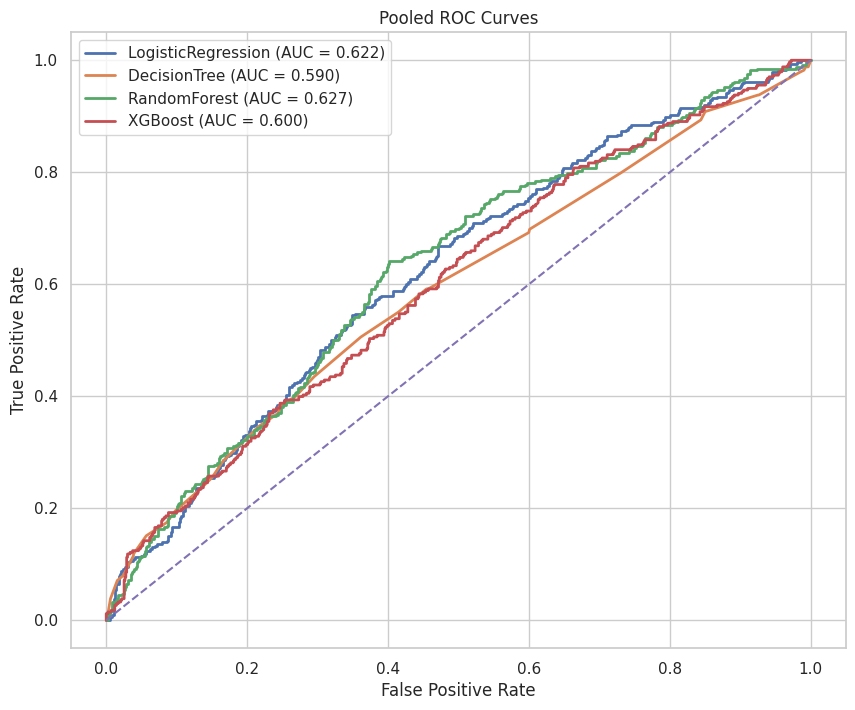

In [ ]:
# =====================================================
# POOLED ROC CURVES
# =====================================================

plt.figure(figsize=(10,8))

models_list = results_ae['model'].unique()

for model_name in models_list:

    model_df = results_ae[
        results_ae['model'] == model_name
    ]

    # -------------------------------------------------
    # POOL OUTER-FOLD PREDICTIONS
    # -------------------------------------------------

    y_true = np.concatenate(
        model_df['y_true'].values
    )

    y_proba = np.concatenate(
        model_df['y_proba'].values
    )

    # -------------------------------------------------
    # ROC
    # -------------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_true,
        y_proba
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

# -----------------------------------------------------
# RANDOM CLASSIFIER
# -----------------------------------------------------

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Pooled ROC Curves')
plt.legend()
plt.grid(True)

plt.show()

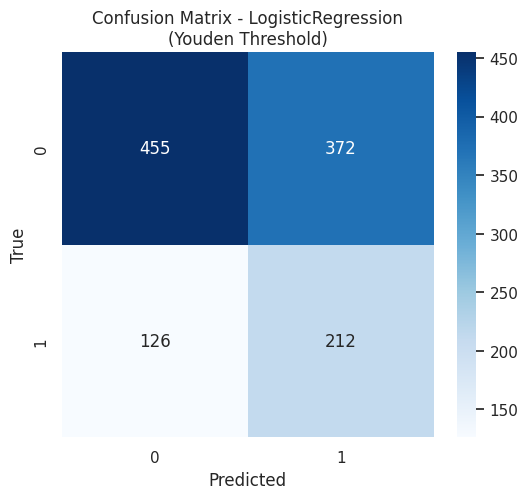

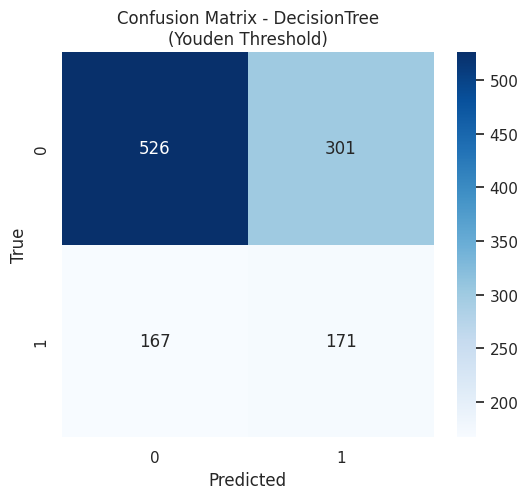

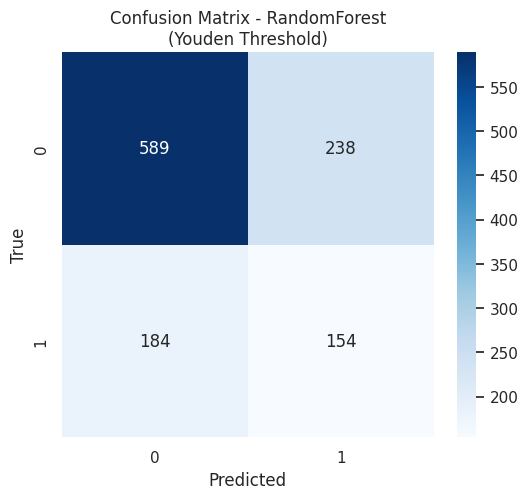

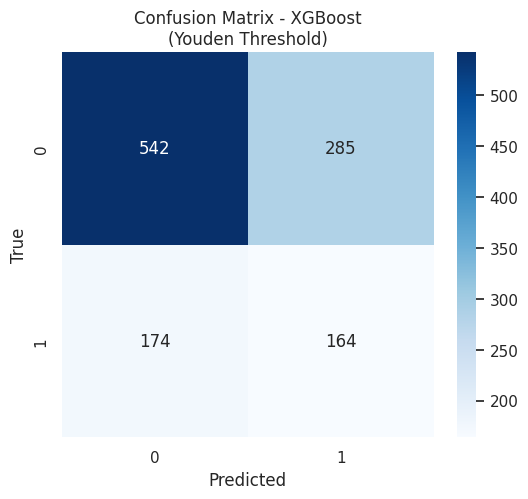

In [ ]:
# =====================================================
# CONFUSION MATRICES USING STORED YOUDEN PREDICTIONS
# =====================================================

for model_name in results_ae['model'].unique():

    model_df = results_ae[
        results_ae['model'] == model_name
    ]

    # ---------------------------------------------
    # POOL FOLD PREDICTIONS
    # ---------------------------------------------

    y_true = np.concatenate(
        model_df['y_true'].values
    )

    # These predictions already use the
    # Youden threshold computed inside CV
    y_pred = np.concatenate(
        model_df['y_pred'].values
    )

    # ---------------------------------------------
    # CONFUSION MATRIX
    # ---------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    # Optional: mean threshold across folds
    if 'best_threshold' in model_df.columns:
        mean_threshold = model_df[
            'best_threshold'
        ].mean()

        title = (
            f'Confusion Matrix - {model_name}\n'
            f'(Youden Threshold mean = {mean_threshold:.3f})'
        )
    else:
        title = (
            f'Confusion Matrix - {model_name}\n'
            f'(Youden Threshold)'
        )

    # ---------------------------------------------
    # PLOT
    # ---------------------------------------------

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)

    plt.xlabel('Predicted')
    plt.ylabel('True')

    plt.show()

### Inference on Test Set

AE Epoch 20/100 - Loss: 0.173856
AE Epoch 40/100 - Loss: 0.128850
AE Epoch 60/100 - Loss: 0.127148
AE Epoch 80/100 - Loss: 0.123714
AE Epoch 100/100 - Loss: 0.120074

Train NaNs: 0
Test NaNs: 0
Fitting 5 folds for each of 8 candidates, totalling 40 fits

BEST PARAMETERS
{'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2'}

Best Youden Threshold: 0.5011

HELD-OUT TEST RESULTS
Accuracy : 0.6214
AUC      : 0.6156
F1 Score : 0.4583
Precision: 0.3929
Recall   : 0.5500


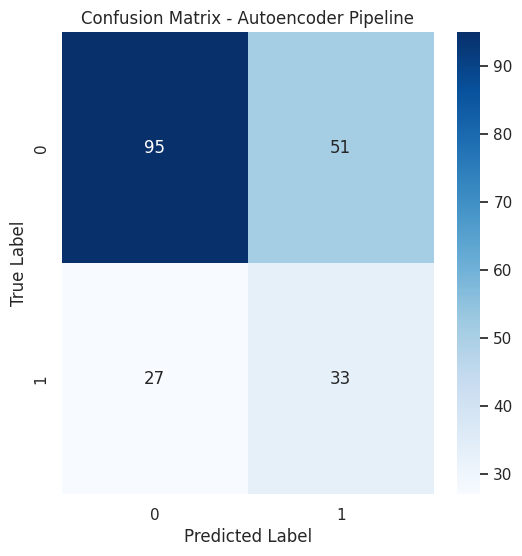

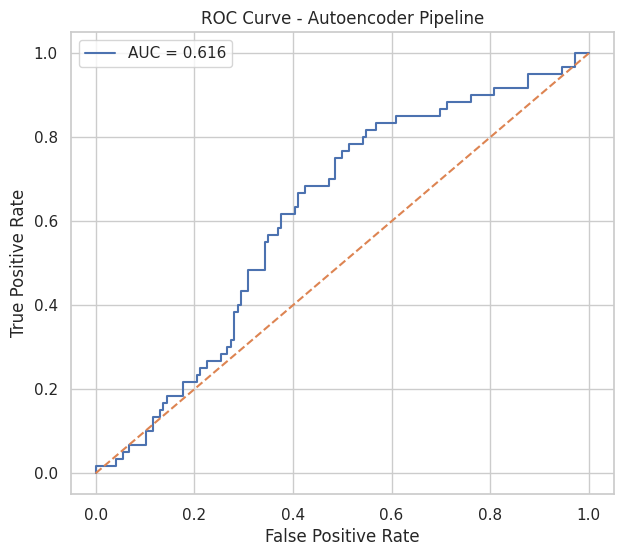

In [ ]:
# =========================================================
# LOAD TEST SET
# =========================================================

test_path = "support2_test.xlsx"

df_test = pd.read_excel(test_path)

target_col = "target"

# =========================================================
# TRAIN = FULL TRAINING DATA
# =========================================================

train_df = df_cv.copy()

# =========================================================
# IMPUTATION
# FIT ONLY ON TRAIN
# =========================================================

imputation_dict = custom_imputation_fit(
    train_df
)

train_df = custom_imputation_transform(
    train_df,
    imputation_dict
)

df_test = custom_imputation_transform(
    df_test,
    imputation_dict
)

# =========================================================
# PREPROCESSING
# FIT ONLY ON TRAIN
# =========================================================

preprocess_dict = preprocessing_fit(
    train_df
)

train_df = preprocessing_transform(
    train_df,
    preprocess_dict
)

df_test = preprocessing_transform(
    df_test,
    preprocess_dict
)

# =========================================================
# SPLIT FEATURES / TARGET
# =========================================================

X_train_proc = train_df.drop(columns=[target_col])

y_train = train_df[target_col]

X_test_proc = df_test.drop(columns=[target_col])

y_test = df_test[target_col]

# =========================================================
# ALIGN TEST FEATURES
# =========================================================

for col in X_train_proc.columns:

    if col not in X_test_proc.columns:
        X_test_proc[col] = 0

X_test_proc = X_test_proc[
    X_train_proc.columns
]

# =========================================================
# IDENTIFY BASELINE PROCESSED COLUMNS
# =========================================================

baseline_processed_cols = []

for col in X_train_proc.columns:

    if (
        col in [
            'age',
            'sex',
            'edu',
            'num.co',
            'diabetes',
            'metastatic'
        ]
        or col.startswith('race_')
        or col.startswith('income_')
    ):

        baseline_processed_cols.append(col)

# =========================================================
# OTHER FEATURES
# =========================================================

other_features = [

    col for col in X_train_proc.columns

    if col not in baseline_processed_cols
]

# =========================================================
# SPLIT BASELINE / OTHER
# =========================================================

X_train_base = X_train_proc[
    baseline_processed_cols
].copy()

X_test_base = X_test_proc[
    baseline_processed_cols
].copy()

X_train_other = X_train_proc[
    other_features
].copy()

X_test_other = X_test_proc[
    other_features
].copy()

# =========================================================
# FLOAT CONVERSION
# =========================================================

X_train_base = X_train_base.astype(float)

X_test_base = X_test_base.astype(float)

# =========================================================
# TORCH TENSORS
# =========================================================

X_train_tensor = torch.tensor(
    X_train_base.values,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_base.values,
    dtype=torch.float32
)

# =========================================================
# DATA LOADER
# =========================================================

ae_batch_size = 32

train_dataset = TensorDataset(
    X_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=ae_batch_size,
    shuffle=True
)

# =========================================================
# AUTOENCODER SETTINGS
# =========================================================

embedding_dim = 3

ae_epochs = 100

ae_lr = 1e-3

# =========================================================
# AUTOENCODER
# =========================================================

input_dim = X_train_base.shape[1]

autoencoder = Autoencoder(
    input_dim=input_dim,
    embedding_dim=embedding_dim
)

# =========================================================
# LOSS + OPTIMIZER
# =========================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=ae_lr
)

# =========================================================
# TRAIN AUTOENCODER
# =========================================================

autoencoder.train()

for epoch in range(ae_epochs):

    epoch_loss = 0

    for batch in train_loader:

        batch_x = batch[0]

        optimizer.zero_grad()

        reconstruction = autoencoder(batch_x)

        loss = criterion(
            reconstruction,
            batch_x
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 20 == 0:

        print(
            f"AE Epoch {epoch+1}/{ae_epochs} "
            f"- Loss: "
            f"{epoch_loss / len(train_loader):.6f}"
        )

# =========================================================
# EXTRACT EMBEDDINGS
# =========================================================

autoencoder.eval()

with torch.no_grad():

    train_embeddings = autoencoder.encoder(
        X_train_tensor
    ).numpy()

    test_embeddings = autoencoder.encoder(
        X_test_tensor
    ).numpy()

# =========================================================
# EMBEDDING DATAFRAMES
# =========================================================

embedding_cols = [

    f'baseline_emb{i+1}'

    for i in range(embedding_dim)
]

X_train_emb_df = pd.DataFrame(
    train_embeddings,
    columns=embedding_cols,
    index=X_train_proc.index
)

X_test_emb_df = pd.DataFrame(
    test_embeddings,
    columns=embedding_cols,
    index=X_test_proc.index
)

# =========================================================
# FINAL DATASETS
# =========================================================

X_train_final = pd.concat(
    [
        X_train_other,
        X_train_emb_df
    ],
    axis=1
)

X_test_final = pd.concat(
    [
        X_test_other,
        X_test_emb_df
    ],
    axis=1
)

# =========================================================
# FINAL FLOAT CONVERSION
# =========================================================

X_train_final = X_train_final.astype(float)

X_test_final = X_test_final.astype(float)

# =========================================================
# CHECK NaNs
# =========================================================

print("\nTrain NaNs:", X_train_final.isna().sum().sum())

print("Test NaNs:", X_test_final.isna().sum().sum())

# =========================================================
# BALANCING
# =========================================================

under = RandomUnderSampler(
    sampling_strategy=0.67,
    random_state=42
)

smote = SMOTE(
    random_state=42
)

# =========================================================
# LOGISTIC REGRESSION PIPELINE
# =========================================================

pipeline = ImbPipeline([

    ('under', under),

    ('smote', smote),

    ('model',
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

# =========================================================
# PARAM GRID
# =========================================================

param_grid = {

    'model__C': [0.01, 0.1, 1, 10],

    'model__penalty': ['l2'],

    'model__class_weight': [
        None,
        'balanced'
    ]
}

# =========================================================
# INNER CV
# =========================================================

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# GRID SEARCH
# =========================================================

grid = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring='roc_auc',

    cv=inner_cv,

    n_jobs=-1,

    verbose=1
)

# =========================================================
# TRAIN FINAL MODEL
# =========================================================

grid.fit(
    X_train_final,
    y_train
)

# =========================================================
# BEST MODEL
# =========================================================

final_model = grid.best_estimator_

print("\n================================================")
print("BEST PARAMETERS")
print("================================================")

print(grid.best_params_)

# =========================================================
# TRAIN PROBABILITIES
# =========================================================

y_train_proba = final_model.predict_proba(
    X_train_final
)[:,1]

# =========================================================
# YOUDEN THRESHOLD
# =========================================================

fpr, tpr, thresholds = roc_curve(
    y_train,
    y_train_proba
)

youden_j = tpr - fpr

best_threshold = thresholds[
    np.argmax(youden_j)
]

print(f"\nBest Youden Threshold: {best_threshold:.4f}")

# =========================================================
# TEST INFERENCE
# =========================================================

y_test_proba = final_model.predict_proba(
    X_test_final
)[:,1]

y_test_pred = (
    y_test_proba >= best_threshold
).astype(int)

# =========================================================
# TEST METRICS
# =========================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

# =========================================================
# PRINT RESULTS
# =========================================================

print("\n================================================")
print("HELD-OUT TEST RESULTS")
print("================================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"AUC      : {test_auc:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "Confusion Matrix - Autoencoder Pipeline"
)

plt.show()

# =========================================================
# ROC CURVE
# =========================================================

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"AUC = {test_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Autoencoder Pipeline"
)

plt.legend()

plt.show()